# Exploratory Data Analysis

In this notebook, I first build the dataset that I use in my thesis. Then I study the final target panel, the source climate panel, and the source-target similarity structure.


# Aim

In this chapter, I ask one practical question: is my Amsterdam groundwater dataset strong enough for the modelling work that follows? I answer this by checking target selection, time coverage, target-variable behaviour, driver relationships, and source-target similarity.


# Workflow

I keep the full workflow in one notebook. I first build the processed tables inside the EDA, and then I use these tables for the analysis. I show one result after each part so that the pipeline is easy to audit.


In [1]:
from pathlib import Path
import csv
import json
import sqlite3
import time
import warnings
from typing import Iterable
from urllib.error import HTTPError, URLError
from urllib.request import Request, urlopen

import fiona
import geopandas as gpd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyogrio
import seaborn as sns
import xarray as xr
from IPython.display import display
from shapely.geometry import box
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings('ignore', category=FutureWarning)

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 240,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
})

ROOT = Path.cwd().resolve()
if ROOT.name.lower() in {'data', 'code'}:
    ROOT = ROOT.parent

BASELINE_ROOT = ROOT / 'baseline' / 'groundwater_thesis_SARP'
DATASETS_DIR = ROOT / 'Data' / 'Datasets'
GROUNDWATER_DIR = ROOT / 'Data' / 'Amsterdam_gw_data'
OUT_DIR = ROOT / 'Data' / 'processed'
EDA_DIR = OUT_DIR / 'eda' / 'tables'
FIG_DIR = OUT_DIR / 'eda' / 'figures'
TARGET_UNIVERSE_DIR = OUT_DIR / 'eda' / 'target_universe'
MODEL_INPUTS_DIR = OUT_DIR / 'model_inputs'
EDA_TABLE_GROUPS = {
    'overview': {
        'corpus_overview.csv',
        'feature_missingness.csv',
    },
    'correlations': {
        'pooled_lag_correlations.csv',
        'site_best_lag_summary.csv',
        'site_lag_correlations.csv',
    },
    'similarity': {
        'source_target_best_matches.csv',
        'source_target_best_matches_train.csv',
        'source_target_similarity.csv',
        'source_target_similarity_train.csv',
    },
}
EDA_FIGURE_GROUPS = {
    'overview': {
        'target_sites_map.png',
        'target_site_coverage_distribution.png',
        'feature_missingness_share.png',
        'local_wtda_distribution.png',
        'seasonal_wtda_boxplot.png',
        'standardized_monthly_signals.png',
        'representative_well_timeseries.png',
        'dataset_coverage_timeline.png',
    },
    'correlations': {
        'lagged_correlation_heatmap.png',
        'site_heterogeneity_correlation_heatmap.png',
    },
    'similarity': {
        'source_target_similarity_distribution.png',
        'best_source_similarity_by_site.png',
    },
}
EDA_TABLE_DIRS = {group: EDA_DIR / group for group in EDA_TABLE_GROUPS}
EDA_FIGURE_DIRS = {group: FIG_DIR / group for group in EDA_FIGURE_GROUPS}
EDA_TABLE_PATHS = {
    filename: EDA_TABLE_DIRS[group] / filename
    for group, filenames in EDA_TABLE_GROUPS.items()
    for filename in filenames
}
EDA_FIGURE_PATHS = {
    filename: EDA_FIGURE_DIRS[group] / filename
    for group, filenames in EDA_FIGURE_GROUPS.items()
    for filename in filenames
}

OUT_DIR.mkdir(parents=True, exist_ok=True)
EDA_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
TARGET_UNIVERSE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_INPUTS_DIR.mkdir(parents=True, exist_ok=True)
for directory in EDA_TABLE_DIRS.values():
    directory.mkdir(parents=True, exist_ok=True)
for directory in EDA_FIGURE_DIRS.values():
    directory.mkdir(parents=True, exist_ok=True)

MONITOR_GPKG = DATASETS_DIR / 'brogmkenset.gpkg'
USE_GPKG = DATASETS_DIR / 'bro_groundwater_use.gpkg'
CACHE_DIR = GROUNDWATER_DIR
TARGET_WELLS_PATH = TARGET_UNIVERSE_DIR / 'selected_target_wells.csv'
TARGET_TUBES_PATH = TARGET_UNIVERSE_DIR / 'download_universe_tubes.csv'
TARGET_SUMMARY_PATH = TARGET_UNIVERSE_DIR / 'selection_summary.json'

HORIZON = 3
TARGET_DISTANCE_METERS = 50
BUFFER_METERS = 5000
K_NEIGHBORS = 5
PRETRAIN_MAX_CELLS = 512
PRETRAIN_MIN_VALID_RATIO = 1.00
PRETRAIN_RANDOM_SEED = 42
SIMILARITY_MAX_LAG = 6

REGION_PRESETS = {
    'zuid_holland': (3.6, 51.7, 5.1, 52.3),
    'amsterdam': (4.55, 52.20, 5.15, 52.50),
}
REGION_NAME = 'amsterdam'
REGION_BBOX = REGION_PRESETS[REGION_NAME]
ZH_BBOX = REGION_BBOX
METRIC_CRS = 'EPSG:28992'
SOURCE_CRS = 'EPSG:4258'
BRO_GLD_CSV_URL = 'https://publiek.broservices.nl/gm/gld/v1/objectsAsCsv/{gld_id}'

MIN_OBS = 500
MIN_FIRST_DATE = pd.Timestamp('2010-01-01')
MIN_LAST_DATE = pd.Timestamp('2020-01-01')
SPLIT_RATIOS = {'train': 0.60, 'val': 0.15, 'cal': 0.10, 'test': 0.15}

REFRESH_TARGET_DOWNLOAD_UNIVERSE = False
DOWNLOAD_TARGET_CACHE = False
REPLACE_TARGET_CACHE = False
TARGET_CACHE_SLEEP_SECONDS = 0.20


def eda_table_path(filename: str) -> Path:
    return EDA_TABLE_PATHS.get(filename, EDA_DIR / filename)


def eda_figure_path(filename: str) -> Path:
    return EDA_FIGURE_PATHS.get(filename, FIG_DIR / filename)


def save_and_show(fig: plt.Figure, filename: str):
    out = eda_figure_path(filename)
    out.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out, bbox_inches='tight')
    plt.close(fig)
    print('Saved:', out)


print('ROOT:', ROOT)
print('REGION_NAME:', REGION_NAME)
print('REGION_BBOX:', REGION_BBOX)
print('OUT_DIR:', OUT_DIR)
print('EDA_DIR:', EDA_DIR)
print('FIG_DIR:', FIG_DIR)


ROOT: /Users/izhan/Desktop/groundwater/stephanie_thesis_groundwater
REGION_NAME: amsterdam
REGION_BBOX: (4.55, 52.2, 5.15, 52.5)
OUT_DIR: /Users/izhan/Desktop/groundwater/stephanie_thesis_groundwater/Data/processed
EDA_DIR: /Users/izhan/Desktop/groundwater/stephanie_thesis_groundwater/Data/processed/eda_thesis
FIG_DIR: /Users/izhan/Desktop/groundwater/stephanie_thesis_groundwater/Data/processed/figures_eda


## Target Download Universe

Here I define the Amsterdam target wells that I keep for the thesis. I use this same target definition in the EDA and in the later modelling tables.


In [2]:
def load_monitoring_tubes_with_series(bbox_tuple: tuple[float, float, float, float]) -> gpd.GeoDataFrame:
    tubes = pyogrio.read_dataframe(
        MONITOR_GPKG,
        layer='gm_gmw_monitoringtube',
        bbox=bbox_tuple,
        fid_as_index=True,
    )
    tubes = (
        tubes.reset_index()
        .rename(columns={'fid': 'site_id', 'gm_gmw_fk': 'well_id'})
        [['site_id', 'well_id', 'gmw_bro_id', 'tube_number', 'geometry']]
    )
    tubes = gpd.GeoDataFrame(tubes, geometry='geometry', crs=SOURCE_CRS).to_crs(METRIC_CRS)

    series = pyogrio.read_dataframe(MONITOR_GPKG, layer='gm_gld', fid_as_index=True)
    series['number_of_observations'] = pd.to_numeric(series['number_of_observations'], errors='coerce')
    series['research_first_date'] = pd.to_datetime(series['research_first_date'], errors='coerce')
    series['research_last_date'] = pd.to_datetime(series['research_last_date'], errors='coerce')

    series_agg = series.groupby('gm_gmw_monitoringtube_fk', as_index=False).agg(
        n_gld_series=('gm_gmw_monitoringtube_fk', 'size'),
        max_observations_meta=('number_of_observations', 'max'),
        sum_observations_meta=('number_of_observations', 'sum'),
        first_date_meta=('research_first_date', 'min'),
        last_date_meta=('research_last_date', 'max'),
    )

    tubes = (
        tubes.merge(
            series_agg,
            left_on='site_id',
            right_on='gm_gmw_monitoringtube_fk',
            how='inner',
        )
        .drop(columns=['gm_gmw_monitoringtube_fk'])
        .reset_index(drop=True)
    )
    tubes_wgs84 = tubes.to_crs('EPSG:4326')
    tubes['lon'] = tubes_wgs84.geometry.x
    tubes['lat'] = tubes_wgs84.geometry.y
    return tubes


def load_groundwater_use_sources(
    bbox_tuple: tuple[float, float, float, float],
) -> tuple[gpd.GeoDataFrame, dict[str, int]]:
    bbox_geom = box(*bbox_tuple)

    facility = pyogrio.read_dataframe(USE_GPKG, layer='groundwater_usage_facility', bbox=bbox_tuple)
    facility = gpd.GeoDataFrame(facility[['bro_id', 'geometry']], geometry='geometry', crs=SOURCE_CRS)
    facility = facility.explode(index_parts=False).reset_index(drop=True).to_crs(METRIC_CRS)
    facility['use_obj_type'] = 'facility_point'
    facility['use_obj_id'] = facility['bro_id'].astype(str)
    facility['facility_bro_id'] = facility['bro_id'].astype(str)

    conn = sqlite3.connect(USE_GPKG)
    try:
        loc = pd.read_sql_query(
            'SELECT bro_location_pk, design_well_fk, realised_well_fk FROM bro_location',
            conn,
        )
        pt = pd.read_sql_query(
            'SELECT bro_location_fk, x_or_lon, y_or_lat FROM bro_point',
            conn,
        )
        pt['x'] = pd.to_numeric(pt['x_or_lon'], errors='coerce')
        pt['y'] = pd.to_numeric(pt['y_or_lat'], errors='coerce')
        points = gpd.GeoDataFrame(
            pt[['bro_location_fk', 'x', 'y']],
            geometry=gpd.points_from_xy(pt['x'], pt['y']),
            crs=METRIC_CRS,
        )

        realised_well = pd.read_sql_query(
            'SELECT realised_well_pk, realised_well_id FROM realised_well',
            conn,
        )
        design_well = pd.read_sql_query(
            'SELECT design_well_pk, design_well_id FROM design_well',
            conn,
        )

        realised = (
            loc.dropna(subset=['realised_well_fk'])
            .merge(points, left_on='bro_location_pk', right_on='bro_location_fk', how='inner')
            .merge(realised_well, left_on='realised_well_fk', right_on='realised_well_pk', how='left')
        )
        realised = gpd.GeoDataFrame(
            realised[['realised_well_id', 'geometry']],
            geometry='geometry',
            crs=METRIC_CRS,
        ).to_crs('EPSG:4326')
        realised = realised[realised.within(bbox_geom)].to_crs(METRIC_CRS).reset_index(drop=True)
        realised['use_obj_type'] = 'realised_well'
        realised['use_obj_id'] = realised['realised_well_id'].astype(str)
        realised['facility_bro_id'] = pd.NA

        design = (
            loc.dropna(subset=['design_well_fk'])
            .merge(points, left_on='bro_location_pk', right_on='bro_location_fk', how='inner')
            .merge(design_well, left_on='design_well_fk', right_on='design_well_pk', how='left')
        )
        design = gpd.GeoDataFrame(
            design[['design_well_id', 'geometry']],
            geometry='geometry',
            crs=METRIC_CRS,
        ).to_crs('EPSG:4326')
        design = design[design.within(bbox_geom)].to_crs(METRIC_CRS).reset_index(drop=True)
        design['use_obj_type'] = 'design_well'
        design['use_obj_id'] = design['design_well_id'].astype(str)
        design['facility_bro_id'] = pd.NA
    finally:
        conn.close()

    sources = pd.concat(
        [
            facility[['use_obj_type', 'use_obj_id', 'facility_bro_id', 'geometry']],
            realised[['use_obj_type', 'use_obj_id', 'facility_bro_id', 'geometry']],
            design[['use_obj_type', 'use_obj_id', 'facility_bro_id', 'geometry']],
        ],
        ignore_index=True,
    )
    sources = gpd.GeoDataFrame(sources, geometry='geometry', crs=METRIC_CRS)

    counts = {
        'facility_points_bbox': int(len(facility)),
        'facility_objects_bbox': int(facility['bro_id'].nunique()),
        'realised_well_points_bbox': int(len(realised)),
        'realised_wells_bbox': int(realised['realised_well_id'].nunique()),
        'design_well_points_bbox': int(len(design)),
        'design_wells_bbox': int(design['design_well_id'].nunique()),
    }
    return sources, counts


def build_universe(
    tubes: gpd.GeoDataFrame,
    sources: gpd.GeoDataFrame,
    distance_meters: float,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    nearest = gpd.sjoin_nearest(
        tubes,
        sources,
        how='left',
        distance_col='distance_to_use_m',
    )
    nearest = (
        nearest.sort_values(['site_id', 'distance_to_use_m', 'use_obj_type', 'use_obj_id'])
        .drop_duplicates('site_id')
        .reset_index(drop=True)
    )

    selected = nearest[
        (nearest['distance_to_use_m'] <= distance_meters)
        & (nearest['first_date_meta'] <= MIN_FIRST_DATE)
        & (nearest['last_date_meta'] >= MIN_LAST_DATE)
    ].copy()

    selected['tube_rank_within_well_meta'] = (
        selected.sort_values(
            ['well_id', 'distance_to_use_m', 'sum_observations_meta', 'tube_number', 'site_id'],
            ascending=[True, True, False, True, True],
        )
        .groupby('well_id')
        .cumcount()
        + 1
    )
    return nearest, selected


def build_gld_download_table(selected_tubes: pd.DataFrame) -> pd.DataFrame:
    gld = pyogrio.read_dataframe(MONITOR_GPKG, layer='gm_gld', fid_as_index=True)
    gld = gld.rename(columns={'bro_id': 'gld_bro_id'})
    gld['research_first_date'] = pd.to_datetime(gld['research_first_date'], errors='coerce')
    gld['research_last_date'] = pd.to_datetime(gld['research_last_date'], errors='coerce')
    gld['number_of_observations'] = pd.to_numeric(gld['number_of_observations'], errors='coerce')

    out = selected_tubes[
        [
            'site_id',
            'well_id',
            'gmw_bro_id',
            'tube_number',
            'distance_to_use_m',
            'use_obj_type',
            'use_obj_id',
            'tube_rank_within_well_meta',
        ]
    ].merge(
        gld[
            [
                'gm_gmw_monitoringtube_fk',
                'gld_bro_id',
                'number_of_observations',
                'research_first_date',
                'research_last_date',
                'series_unknown_csv_url',
                'series_preliminary_csv_url',
                'series_fully_assessed_csv_url',
            ]
        ],
        left_on='site_id',
        right_on='gm_gmw_monitoringtube_fk',
        how='left',
    )
    out = out.drop(columns=['gm_gmw_monitoringtube_fk']).rename(
        columns={
            'number_of_observations': 'gld_observations_meta',
            'research_first_date': 'gld_first_date_meta',
            'research_last_date': 'gld_last_date_meta',
        }
    )
    out['bro_csv_url'] = out['gld_bro_id'].map(lambda x: BRO_GLD_CSV_URL.format(gld_id=x))
    out = out.sort_values(['site_id', 'gld_bro_id']).reset_index(drop=True)
    return out


def iter_measurements_from_bro_csv(raw_text: str) -> Iterable[tuple[str, float]]:
    reader = csv.reader(raw_text.splitlines())
    for row in reader:
        if len(row) < 2:
            continue
        ts = row[0].strip().strip('"')
        val = row[1].strip().strip('"')
        if not ts or not val:
            continue
        if ts.startswith('tijdstip meting') or ts.startswith('observatie ID') or ts.startswith('BRO-ID'):
            continue
        try:
            water_level = float(val)
        except ValueError:
            continue
        if ts[:4].isdigit():
            yield ts, water_level


def fetch_bro_csv(gld_id: str, retries: int = 6, sleep_seconds: float = 0.20) -> str:
    url = BRO_GLD_CSV_URL.format(gld_id=gld_id)
    req = Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    last_error: Exception | None = None
    for attempt in range(retries):
        try:
            with urlopen(req, timeout=90) as resp:
                return resp.read().decode('utf-8', errors='replace')
        except (HTTPError, URLError, TimeoutError) as exc:
            last_error = exc
            wait = sleep_seconds * (2 ** attempt)
            time.sleep(wait)
    raise RuntimeError(f'Failed to download {gld_id}: {last_error}')


def refresh_cache(download_glds: pd.DataFrame, replace_cache: bool, sleep_seconds: float) -> pd.DataFrame:
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    if replace_cache:
        for fp in CACHE_DIR.glob('*.csv'):
            fp.unlink()

    rows = []
    total = len(download_glds)
    for idx, rec in enumerate(download_glds.itertuples(index=False), start=1):
        site_id = int(rec.site_id)
        gld_id = str(rec.gld_bro_id)
        cache_path = CACHE_DIR / f'{site_id}_{gld_id}.csv'
        status = 'downloaded'
        actual_rows = 0
        actual_first_date = pd.NaT
        actual_last_date = pd.NaT
        cache_rel = pd.NA
        try:
            raw_text = fetch_bro_csv(gld_id=gld_id, sleep_seconds=sleep_seconds)
            measurements = list(iter_measurements_from_bro_csv(raw_text))
            if measurements:
                with cache_path.open('w', newline='', encoding='utf-8') as fh:
                    writer = csv.writer(fh)
                    writer.writerow(['date', 'water_level_nap_m'])
                    writer.writerows(measurements)
                dates = pd.to_datetime([m[0] for m in measurements], errors='coerce', utc=True).tz_convert(None)
                actual_rows = int(len(measurements))
                actual_first_date = dates.min()
                actual_last_date = dates.max()
                cache_rel = str(cache_path.relative_to(ROOT))
            else:
                status = 'empty'
        except Exception as exc:
            status = f'error: {exc}'

        rows.append(
            {
                'site_id': site_id,
                'gld_bro_id': gld_id,
                'cache_path': cache_rel,
                'download_status': status,
                'actual_observation_rows': actual_rows,
                'actual_first_date': actual_first_date,
                'actual_last_date': actual_last_date,
            }
        )
        if idx % 25 == 0 or idx == total:
            print(f'Downloaded {idx}/{total} GLD files')
        time.sleep(sleep_seconds)

    return pd.DataFrame(rows)


def summarize_actual_downloads(
    download_glds: pd.DataFrame,
    actual_glds: pd.DataFrame,
    selected_tubes: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    if actual_glds.empty:
        tube_actual = selected_tubes.copy()
        tube_actual['actual_observation_rows'] = pd.NA
        tube_actual['actual_first_date'] = pd.NaT
        tube_actual['actual_last_date'] = pd.NaT
        tube_actual['downloaded_gld_count'] = 0
    else:
        gld_actual = download_glds.merge(actual_glds, on=['site_id', 'gld_bro_id'], how='left')
        tube_actual = gld_actual.groupby('site_id', as_index=False).agg(
            downloaded_gld_count=('download_status', lambda s: int((pd.Series(s).fillna('') == 'downloaded').sum())),
            actual_observation_rows=('actual_observation_rows', 'sum'),
            actual_first_date=('actual_first_date', 'min'),
            actual_last_date=('actual_last_date', 'max'),
        )
        tube_actual = selected_tubes.merge(tube_actual, on='site_id', how='left')

    target_wells = (
        tube_actual.sort_values(
            [
                'well_id',
                'distance_to_use_m',
                'actual_observation_rows',
                'sum_observations_meta',
                'tube_number',
                'site_id',
            ],
            ascending=[True, True, False, False, True, True],
            na_position='last',
        )
        .drop_duplicates('well_id', keep='first')
        .reset_index(drop=True)
    )
    target_wells['tube_rank_within_well_actual'] = 1
    return tube_actual, target_wells


def write_target_universe_outputs(
    all_tubes: pd.DataFrame,
    selected_tubes: pd.DataFrame,
    download_glds: pd.DataFrame,
    tube_actual: pd.DataFrame,
    target_wells: pd.DataFrame,
    summary: dict,
) -> None:
    TARGET_UNIVERSE_DIR.mkdir(parents=True, exist_ok=True)

    all_tubes.drop(columns=['geometry'], errors='ignore').to_csv(
        TARGET_UNIVERSE_DIR / 'amsterdam_monitoring_tubes_with_use_context.csv',
        index=False,
    )
    selected_tubes.drop(columns=['geometry'], errors='ignore').to_csv(
        TARGET_UNIVERSE_DIR / 'download_universe_tubes.csv',
        index=False,
    )
    download_glds.to_csv(TARGET_UNIVERSE_DIR / 'download_universe_glds.csv', index=False)
    tube_actual.drop(columns=['geometry'], errors='ignore').to_csv(
        TARGET_UNIVERSE_DIR / 'download_universe_tubes_with_actual_counts.csv',
        index=False,
    )
    target_wells.drop(columns=['geometry'], errors='ignore').to_csv(
        TARGET_UNIVERSE_DIR / 'selected_target_wells.csv',
        index=False,
    )
    with (TARGET_UNIVERSE_DIR / 'selection_summary.json').open('w', encoding='utf-8') as fh:
        json.dump(summary, fh, indent=2, default=str)

    summary_md = [
        '# Target Download Universe',
        '',
        'I define the target download universe from monitoring tubes that:',
        f"- fall inside the Amsterdam study bbox `{summary['region_bbox']}`;",
        '- have at least one BRO GLD series in `brogmkenset.gpkg`;',
        (
            '- lie within '
            f"{summary['target_distance_meters']:.0f} m of an exploded groundwater-use facility point, "
            'design well, or realised well from `bro_groundwater_use.gpkg`;'
        ),
        '- and span the thesis overlap window (`first_date <= 2010-01-01`, `last_date >= 2020-01-01`).',
        '',
        f"Result: `{summary['selected_tubes']} tubes / {summary['selected_wells']} wells / {summary['selected_glds']} GLD files`.",
    ]
    (TARGET_UNIVERSE_DIR / 'selection_summary.md').write_text('\n'.join(summary_md) + '\n', encoding='utf-8')


def build_target_download_universe(
    bbox_tuple: tuple[float, float, float, float] = REGION_BBOX,
    distance_meters: float = TARGET_DISTANCE_METERS,
    download_cache: bool = False,
    replace_cache: bool = False,
    sleep_seconds: float = 0.20,
) -> dict:
    tubes = load_monitoring_tubes_with_series(bbox_tuple)
    sources, source_counts = load_groundwater_use_sources(bbox_tuple)
    all_tubes, selected_tubes = build_universe(
        tubes=tubes,
        sources=sources,
        distance_meters=distance_meters,
    )
    download_glds = build_gld_download_table(selected_tubes)

    actual_glds = pd.DataFrame(columns=['site_id', 'gld_bro_id', 'actual_observation_rows', 'actual_first_date', 'actual_last_date'])
    if download_cache:
        actual_glds = refresh_cache(
            download_glds=download_glds,
            replace_cache=replace_cache,
            sleep_seconds=sleep_seconds,
        )

    tube_actual, target_wells = summarize_actual_downloads(
        download_glds=download_glds,
        actual_glds=actual_glds,
        selected_tubes=selected_tubes,
    )

    summary = {
        'region_bbox': list(bbox_tuple),
        'target_distance_meters': float(distance_meters),
        'min_first_date': str(MIN_FIRST_DATE.date()),
        'min_last_date': str(MIN_LAST_DATE.date()),
        'bbox_tubes_with_series': int(len(tubes)),
        'bbox_wells_with_series': int(tubes['well_id'].nunique()),
        'all_tubes_with_use_context': int(len(all_tubes)),
        'selected_tubes': int(len(selected_tubes)),
        'selected_wells': int(selected_tubes['well_id'].nunique()),
        'selected_glds': int(len(download_glds)),
        'downloaded_cache_files': int((actual_glds.get('download_status', pd.Series(dtype=str)) == 'downloaded').sum()),
        'empty_cache_files': int((actual_glds.get('download_status', pd.Series(dtype=str)) == 'empty').sum()),
        'error_cache_files': int(
            actual_glds.get('download_status', pd.Series(dtype=str)).fillna('').astype(str).str.startswith('error').sum()
        ),
    }
    summary.update(source_counts)

    write_target_universe_outputs(
        all_tubes=all_tubes,
        selected_tubes=selected_tubes,
        download_glds=download_glds,
        tube_actual=tube_actual,
        target_wells=target_wells,
        summary=summary,
    )

    return {
        'all_tubes': all_tubes,
        'selected_tubes': selected_tubes,
        'download_glds': download_glds,
        'actual_glds': actual_glds,
        'tube_actual': tube_actual,
        'target_wells': target_wells,
        'summary': summary,
    }


In [3]:
if REFRESH_TARGET_DOWNLOAD_UNIVERSE or not TARGET_WELLS_PATH.exists() or not TARGET_SUMMARY_PATH.exists():
    print('Building target download universe inside the EDA notebook ...')
    target_universe_artifacts = build_target_download_universe(
        bbox_tuple=REGION_BBOX,
        distance_meters=float(TARGET_DISTANCE_METERS),
        download_cache=bool(DOWNLOAD_TARGET_CACHE),
        replace_cache=bool(REPLACE_TARGET_CACHE),
        sleep_seconds=float(TARGET_CACHE_SLEEP_SECONDS),
    )
    print('Target download universe built:')
    print(target_universe_artifacts['summary'])
else:
    print('Using existing target-universe files:')
    print('-', TARGET_WELLS_PATH)
    print('-', TARGET_SUMMARY_PATH)
    with TARGET_SUMMARY_PATH.open() as fh:
        target_universe_summary = json.load(fh)
    display(pd.DataFrame([target_universe_summary]).T.rename(columns={0: 'value'}))


Using existing target-universe files:
- /Users/izhan/Desktop/groundwater/stephanie_thesis_groundwater/Data/processed/target_download_universe/selected_target_wells.csv
- /Users/izhan/Desktop/groundwater/stephanie_thesis_groundwater/Data/processed/target_download_universe/selection_summary.json


,value
region_bbox,"[4.55, 52.2, 5.15, 52.5]"
target_distance_meters,50.0
min_first_date,2010-01-01
min_last_date,2020-01-01
bbox_tubes_with_series,7911
bbox_wells_with_series,6955
all_tubes_with_use_context,7911
selected_tubes,113
selected_wells,102
selected_glds,207


## Reusable Processing Functions

Here I load the data-processing code that I need for the rest of the notebook. I keep the raw-data logic and the EDA helper logic together here.


In [4]:
class DataLoader:
    """Handles loading of groundwater, climate, and pumping data."""

    @staticmethod
    def first_existing(candidates):
        for p in candidates:
            if p is not None and Path(p).exists():
                return Path(p)
        return None

    @staticmethod
    def month_start(s):
        return pd.to_datetime(s, errors='coerce').dt.to_period('M').dt.to_timestamp()

    @staticmethod
    def read_table_gpkg(gpkg_path: Path, layer: str) -> pd.DataFrame:
        rows = []
        pk_col = f'{layer}_pk'
        with fiona.open(gpkg_path, layer=layer) as src:
            for feat in src:
                rec = dict(feat['properties'])
                fid = feat.get('id')
                if fid is not None:
                    try:
                        rec['_fid'] = int(fid)
                    except Exception:
                        rec['_fid'] = fid
                rows.append(rec)
        df = pd.DataFrame(rows)
        if pk_col not in df.columns and '_fid' in df.columns:
            df[pk_col] = df['_fid']
        return df

    @staticmethod
    def load_target_sites(
        target_wells_path: Path,
        target_summary_path: Path | None = None,
    ) -> pd.DataFrame:
        if not target_wells_path.exists():
            raise FileNotFoundError(
                f'Missing {target_wells_path}. Run the target-universe section in this notebook first.'
            )

        out = pd.read_csv(target_wells_path)
        for c in ['first_date_meta', 'last_date_meta', 'actual_first_date', 'actual_last_date']:
            if c in out.columns:
                out[c] = pd.to_datetime(out[c], errors='coerce')

        if 'actual_observation_rows' in out.columns:
            out['actual_observation_rows'] = pd.to_numeric(out['actual_observation_rows'], errors='coerce')
        if 'max_observations_meta' in out.columns:
            out['max_observations_meta'] = pd.to_numeric(out['max_observations_meta'], errors='coerce')
        if 'max_observations' not in out.columns:
            out['max_observations'] = out.get('actual_observation_rows')
            if 'max_observations_meta' in out.columns:
                out['max_observations'] = out['max_observations'].fillna(out['max_observations_meta'])

        out['site_id'] = pd.to_numeric(out['site_id'], errors='coerce')
        out['well_id'] = pd.to_numeric(out['well_id'], errors='coerce')
        out['lon'] = pd.to_numeric(out['lon'], errors='coerce')
        out['lat'] = pd.to_numeric(out['lat'], errors='coerce')
        out = out.dropna(subset=['site_id', 'well_id', 'lon', 'lat']).copy()
        out['site_id'] = out['site_id'].astype(int)
        out['well_id'] = out['well_id'].astype(int)

        out = gpd.GeoDataFrame(
            out,
            geometry=gpd.points_from_xy(out['lon'], out['lat']),
            crs=4326,
        ).reset_index(drop=True)

        selection_summary = {
            'selected_tubes': int(out['site_id'].nunique()),
            'selected_wells': int(out['well_id'].nunique()),
        }
        if target_summary_path is not None and Path(target_summary_path).exists():
            selection_summary.update(json.loads(Path(target_summary_path).read_text()))
        out.attrs['selection_summary'] = selection_summary
        return out

    @staticmethod
    def read_any_csv(path: Path) -> pd.DataFrame:
        for enc in ['utf-8', 'utf-8-sig', 'latin1']:
            try:
                return pd.read_csv(path, sep=None, engine='python', encoding=enc, on_bad_lines='skip')
            except Exception:
                continue
        return pd.DataFrame()

    @staticmethod
    def parse_bro_cache_file(path: Path) -> pd.DataFrame:
        df = DataLoader.read_any_csv(path)
        if df.empty or df.shape[1] < 2:
            return pd.DataFrame(columns=['date', 'water_level_nap_m'])

        cols = list(df.columns)
        tmp = df[[cols[0], cols[1]]].copy()
        tmp.columns = ['date_raw', 'water_level_nap_m']

        tmp['date'] = pd.to_datetime(tmp['date_raw'], errors='coerce', utc=True)
        try:
            tmp['date'] = tmp['date'].dt.tz_convert(None)
        except Exception:
            tmp['date'] = tmp['date'].dt.tz_localize(None)

        tmp['water_level_nap_m'] = pd.to_numeric(tmp['water_level_nap_m'], errors='coerce')
        tmp = tmp.dropna(subset=['date', 'water_level_nap_m']).copy()
        tmp = tmp[['date', 'water_level_nap_m']].sort_values('date').reset_index(drop=True)
        return tmp

    @staticmethod
    def load_local_groundwater(cache_dir: Path, valid_site_ids: set[int]) -> pd.DataFrame:
        rows = []
        files = sorted(cache_dir.glob('*.csv'))

        for fp in files:
            stem = fp.stem
            # Expected name: <site_id>_<bro_id>.csv
            try:
                site_id = int(stem.split('_')[0])
            except Exception:
                continue

            if site_id not in valid_site_ids:
                continue

            ts = DataLoader.parse_bro_cache_file(fp)
            if ts.empty:
                continue

            ts['site_id'] = site_id
            rows.append(ts)

        if not rows:
            raise ValueError('No local groundwater series parsed from Amsterdam_gw_data.')

        out = pd.concat(rows, ignore_index=True)
        out = out.sort_values(['site_id', 'date']).reset_index(drop=True)
        return out

    @staticmethod
    def _detect_time_col(arr: xr.DataArray) -> str:
        for c in ['time', 'valid_time']:
            if c in arr.dims or c in arr.coords:
                return c
        for c in arr.dims:
            if 'time' in c.lower():
                return c
        raise KeyError('No time coordinate found in DataArray.')

    @staticmethod
    def _detect_spatial_dims(arr: xr.DataArray, time_col: str) -> tuple[str, str]:
        dims = [d for d in arr.dims if d != time_col]
        if len(dims) != 2:
            raise ValueError(f'Expected 2 spatial dims, got {dims}')
        return dims[0], dims[1]

    @staticmethod
    def _coord_1d_values(ds: xr.Dataset, dim_name: str) -> np.ndarray:
        size = int(ds.sizes[dim_name])
        if dim_name in ds.coords:
            vals = np.asarray(ds[dim_name].values)
        elif dim_name in ds.variables and ds[dim_name].ndim == 1:
            vals = np.asarray(ds[dim_name].values)
        else:
            vals = np.arange(size, dtype=float)

        if vals.ndim != 1 or len(vals) != size:
            vals = np.arange(size, dtype=float)

        return vals.astype(float, copy=False)

    @staticmethod
    def _extract_grid_cube(nc_path: Path, var_name: str) -> dict:
        ds = xr.open_dataset(nc_path)
        try:
            if var_name not in ds.variables:
                raise KeyError(f'{var_name} not found in {nc_path.name}')

            arr = ds[var_name]
            time_col = DataLoader._detect_time_col(arr)
            y_dim, x_dim = DataLoader._detect_spatial_dims(arr, time_col)
            arr = arr.transpose(time_col, y_dim, x_dim)

            months = DataLoader.month_start(pd.Series(arr[time_col].values)).to_numpy('datetime64[ns]')
            cube = np.asarray(arr.values, dtype=np.float32)

            y_vals = DataLoader._coord_1d_values(ds, y_dim)
            x_vals = DataLoader._coord_1d_values(ds, x_dim)

            return {
                'cube': cube,
                'months': months,
                'y_values': y_vals,
                'x_values': x_vals,
                'shape': cube.shape[1:],
            }
        finally:
            ds.close()

    @staticmethod
    def load_nc_monthly_mean(nc_path: Path, var_name: str, out_name: str) -> pd.DataFrame:
        ds = xr.open_dataset(nc_path)
        if var_name not in ds.variables:
            ds.close()
            raise KeyError(f'{var_name} not found in {nc_path.name}')

        time_col = next((c for c in ['time', 'valid_time'] if c in ds[var_name].dims or c in ds.coords), None)
        if time_col is None:
            ds.close()
            raise KeyError(f'No time coordinate found in {nc_path.name}')

        arr = ds[var_name]
        reduce_dims = [d for d in arr.dims if d != time_col]
        if reduce_dims:
            arr = arr.mean(dim=reduce_dims, skipna=True)

        out = arr.to_dataframe(name=out_name).reset_index()
        out = out.rename(columns={time_col: 'month'})
        out['month'] = DataLoader.month_start(out['month'])
        out = out[['month', out_name]].copy()
        ds.close()
        return out

    @staticmethod
    def load_baseline_climate(tsmp_path: Path, cosmo_path: Path, gleam_path: Path) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
        tsmp_df = DataLoader.load_nc_monthly_mean(tsmp_path, 'wtd_a', 'tsmp_wtda')
        pra_df = DataLoader.load_nc_monthly_mean(cosmo_path, 'pr_a', 'pr_a')
        sma_df = DataLoader.load_nc_monthly_mean(gleam_path, 'sm_a', 'sm_a')
        return tsmp_df, pra_df, sma_df

    @staticmethod
    def load_pretrain_source_grid(
        tsmp_path: Path,
        cosmo_path: Path,
        gleam_path: Path,
        max_cells: int | None,
        min_valid_ratio: float,
        random_seed: int,
    ) -> pd.DataFrame:
        tsmp = DataLoader._extract_grid_cube(tsmp_path, 'wtd_a')
        pra = DataLoader._extract_grid_cube(cosmo_path, 'pr_a')
        sma = DataLoader._extract_grid_cube(gleam_path, 'sm_a')

        if tsmp['shape'] != pra['shape'] or tsmp['shape'] != sma['shape']:
            raise ValueError(
                f'Spatial shape mismatch: TSMP={tsmp["shape"]}, COSMO={pra["shape"]}, GLEAM={sma["shape"]}'
            )

        tsmp_time = pd.DataFrame({'month': pd.to_datetime(tsmp['months']), 'tsmp_idx': np.arange(len(tsmp['months']), dtype=int)})
        pra_time = pd.DataFrame({'month': pd.to_datetime(pra['months']), 'pra_idx': np.arange(len(pra['months']), dtype=int)})
        sma_time = pd.DataFrame({'month': pd.to_datetime(sma['months']), 'sma_idx': np.arange(len(sma['months']), dtype=int)})

        common = tsmp_time.merge(pra_time, on='month', how='inner').merge(sma_time, on='month', how='inner')
        common = common.sort_values('month').reset_index(drop=True)
        if common.empty:
            raise ValueError('No overlapping months among TSMP/COSMO/GLEAM for pretraining source data.')

        tsmp_cube = tsmp['cube'][common['tsmp_idx'].to_numpy(), :, :]
        pra_cube = pra['cube'][common['pra_idx'].to_numpy(), :, :]
        sma_cube = sma['cube'][common['sma_idx'].to_numpy(), :, :]

        n_time, n_y, n_x = tsmp_cube.shape

        flat_tsmp = tsmp_cube.reshape(n_time, -1)
        flat_pra = pra_cube.reshape(n_time, -1)
        flat_sma = sma_cube.reshape(n_time, -1)

        valid_mask = np.isfinite(flat_tsmp) & np.isfinite(flat_pra) & np.isfinite(flat_sma)
        min_valid_count = max(1, int(np.ceil(min_valid_ratio * n_time)))
        valid_idx = np.where(valid_mask.sum(axis=0) >= min_valid_count)[0]

        if valid_idx.size == 0:
            raise ValueError('No valid grid cells found for pretraining source data.')

        rng = np.random.default_rng(random_seed)
        if max_cells is not None and max_cells > 0 and valid_idx.size > max_cells:
            selected_idx = np.sort(rng.choice(valid_idx, size=int(max_cells), replace=False))
        else:
            selected_idx = np.sort(valid_idx)

        tsmp_sel = flat_tsmp[:, selected_idx]
        pra_sel = flat_pra[:, selected_idx]
        sma_sel = flat_sma[:, selected_idx]

        y_idx = selected_idx // n_x
        x_idx = selected_idx % n_x
        source_y = tsmp['y_values'][y_idx]
        source_x = tsmp['x_values'][x_idx]

        months = pd.to_datetime(common['month']).to_numpy('datetime64[ns]')
        n_cells = len(selected_idx)

        grid_df = pd.DataFrame(
            {
                'month': np.repeat(months, n_cells),
                'cell_id': np.tile(selected_idx.astype(np.int64), len(months)),
                'source_y': np.tile(source_y, len(months)),
                'source_x': np.tile(source_x, len(months)),
                'tsmp_wtda': tsmp_sel.reshape(-1),
                'pr_a': pra_sel.reshape(-1),
                'sm_a': sma_sel.reshape(-1),
            }
        )

        grid_df = grid_df.dropna(subset=['tsmp_wtda', 'pr_a', 'sm_a']).copy()
        grid_df['month'] = pd.to_datetime(grid_df['month'])
        grid_df = grid_df.sort_values(['cell_id', 'month']).reset_index(drop=True)
        return grid_df

    @staticmethod
    def load_pumping_proxy(
        use_gpkg: Path,
        site_meta: pd.DataFrame,
        months: pd.DatetimeIndex,
        bbox: tuple[float, float, float, float],
        buffer_meters: int,
    ) -> pd.DataFrame:
        facilities = gpd.read_file(use_gpkg, layer='groundwater_usage_facility')
        if 'groundwater_usage_facility_pk' not in facilities.columns:
            facilities = facilities.reset_index().rename(columns={'index': 'groundwater_usage_facility_pk'})

        facilities = facilities[['groundwater_usage_facility_pk', 'geometry']].copy()

        licence = DataLoader.read_table_gpkg(use_gpkg, 'licence_groundwater_usage')
        quantity = DataLoader.read_table_gpkg(use_gpkg, 'licensed_quantity')
        validity = DataLoader.read_table_gpkg(use_gpkg, 'validity_period')

        licence = licence[['licence_groundwater_usage_pk', 'groundwater_usage_facility_fk']].copy()
        quantity = quantity[[
            'licence_groundwater_usage_fk',
            'licensed_in_out',
            'maximum_per_hour',
            'maximum_per_day',
            'maximum_per_month',
            'maximum_per_year',
        ]].copy()
        validity = validity[['groundwater_usage_facility_fk', 'start_validity', 'end_validity']].copy()

        quantity['licensed_in_out'] = quantity['licensed_in_out'].astype(str).str.lower().str.strip()
        quantity = quantity[quantity['licensed_in_out'] == 'onttrekken'].copy()

        for c in ['maximum_per_hour', 'maximum_per_day', 'maximum_per_month', 'maximum_per_year']:
            quantity[c] = pd.to_numeric(quantity[c], errors='coerce')

        quantity['annual_m3'] = quantity['maximum_per_year']
        quantity['annual_m3'] = quantity['annual_m3'].fillna(quantity['maximum_per_month'] * 12)
        quantity['annual_m3'] = quantity['annual_m3'].fillna(quantity['maximum_per_day'] * 365)
        quantity['annual_m3'] = quantity['annual_m3'].fillna(quantity['maximum_per_hour'] * 24 * 365)
        quantity['annual_m3'] = quantity['annual_m3'].fillna(0.0).clip(lower=0)

        licence['licence_groundwater_usage_pk'] = pd.to_numeric(licence['licence_groundwater_usage_pk'], errors='coerce')
        licence['groundwater_usage_facility_fk'] = pd.to_numeric(licence['groundwater_usage_facility_fk'], errors='coerce')
        quantity['licence_groundwater_usage_fk'] = pd.to_numeric(quantity['licence_groundwater_usage_fk'], errors='coerce')

        q_licence = quantity.groupby('licence_groundwater_usage_fk', as_index=False)['annual_m3'].sum()
        q_facility = (
            licence.merge(q_licence, left_on='licence_groundwater_usage_pk', right_on='licence_groundwater_usage_fk', how='left')
            .groupby('groundwater_usage_facility_fk', as_index=False)['annual_m3'].sum()
        )
        q_facility['annual_m3'] = q_facility['annual_m3'].fillna(0.0)

        validity['groundwater_usage_facility_fk'] = pd.to_numeric(validity['groundwater_usage_facility_fk'], errors='coerce')
        validity['start_validity'] = pd.to_datetime(validity['start_validity'], errors='coerce')
        validity['end_validity'] = pd.to_datetime(validity['end_validity'], errors='coerce')
        validity['start_validity'] = validity['start_validity'].fillna(pd.Timestamp('1900-01-01'))
        validity['end_validity'] = validity['end_validity'].fillna(pd.Timestamp('2100-12-31'))

        validity_facility = validity.groupby('groundwater_usage_facility_fk', as_index=False).agg(
            valid_start=('start_validity', 'min'),
            valid_end=('end_validity', 'max'),
        )

        facilities['groundwater_usage_facility_pk'] = pd.to_numeric(facilities['groundwater_usage_facility_pk'], errors='coerce')
        facilities = facilities.merge(
            q_facility,
            left_on='groundwater_usage_facility_pk',
            right_on='groundwater_usage_facility_fk',
            how='left',
        )
        facilities = facilities.merge(
            validity_facility,
            left_on='groundwater_usage_facility_pk',
            right_on='groundwater_usage_facility_fk',
            how='left',
        )

        facilities['annual_m3'] = facilities['annual_m3'].fillna(0.0)
        facilities['valid_start'] = facilities['valid_start'].fillna(pd.Timestamp('1900-01-01'))
        facilities['valid_end'] = facilities['valid_end'].fillna(pd.Timestamp('2100-12-31'))

        if facilities.crs is None:
            facilities = facilities.set_crs(4326)
        facilities = facilities.to_crs(4326)

        facilities = facilities.explode(index_parts=False, ignore_index=True)
        facilities = facilities[facilities.geometry.notna()].copy()

        minx, miny, maxx, maxy = bbox
        facilities = facilities.cx[minx:maxx, miny:maxy].copy()
        facilities = facilities[facilities['annual_m3'] > 0].copy()

        sites_m = site_meta[['site_id', 'geometry']].to_crs(28992)
        facilities_m = facilities[['groundwater_usage_facility_pk', 'annual_m3', 'valid_start', 'valid_end', 'geometry']].to_crs(28992)

        site_buffers = sites_m.copy()
        site_buffers['geometry'] = site_buffers.geometry.buffer(buffer_meters)

        pairs = gpd.sjoin(
            facilities_m,
            site_buffers[['site_id', 'geometry']],
            how='inner',
            predicate='within',
        )

        pairs = pairs[['groundwater_usage_facility_pk', 'site_id', 'annual_m3', 'valid_start', 'valid_end']]
        pairs = pairs.drop_duplicates(['groundwater_usage_facility_pk', 'site_id']).copy()

        pairs['valid_start'] = DataLoader.month_start(pairs['valid_start']).fillna(pd.Timestamp('1900-01-01'))
        pairs['valid_end'] = DataLoader.month_start(pairs['valid_end']).fillna(pd.Timestamp('2100-12-01'))

        months_df = pd.DataFrame({'month': months, '_k': 1})
        pairs['_k'] = 1

        pair_month = pairs.merge(months_df, on='_k', how='inner').drop(columns=['_k'])
        pair_month = pair_month[
            (pair_month['month'] >= pair_month['valid_start'])
            & (pair_month['month'] <= pair_month['valid_end'])
        ].copy()

        pair_month['pumping_m3_month'] = pair_month['annual_m3'] / 12.0

        pumping_df = pair_month.groupby(['site_id', 'month'], as_index=False)['pumping_m3_month'].sum()
        return pumping_df


In [5]:
class DataProcessor:
    """Processes data into baseline-aligned training tables."""

    @staticmethod
    def assign_time_splits(month_values: pd.Series, ratios: dict[str, float]) -> pd.Series:
        months = np.array(sorted(pd.to_datetime(month_values).dropna().unique()))
        n = len(months)
        if n == 0:
            return pd.Series(index=month_values.index, dtype='object')

        n_train = max(1, int(n * ratios['train']))
        n_val = max(1, int(n * ratios['val']))
        n_cal = max(1, int(n * ratios['cal']))
        n_test = max(1, n - n_train - n_val - n_cal)

        while n_train + n_val + n_cal + n_test > n:
            if n_test > 1:
                n_test -= 1
            elif n_cal > 1:
                n_cal -= 1
            elif n_val > 1:
                n_val -= 1
            else:
                n_train = max(1, n_train - 1)

        train_end = months[n_train - 1]
        val_end = months[min(n - 1, n_train + n_val - 1)]
        cal_end = months[min(n - 1, n_train + n_val + n_cal - 1)]

        mv = pd.to_datetime(month_values)
        split = np.where(
            mv <= train_end,
            'train',
            np.where(mv <= val_end, 'val', np.where(mv <= cal_end, 'cal', 'test')),
        )
        return pd.Series(split, index=month_values.index)

    @staticmethod
    def calculate_groundwater_anomalies(local_df: pd.DataFrame) -> pd.DataFrame:
        df = local_df.copy()
        df['month_of_year'] = df['date'].dt.month

        stats = (
            df.groupby(['site_id', 'month_of_year'])['water_level_nap_m']
            .agg(['mean', 'std'])
            .reset_index()
            .rename(columns={'mean': 'wl_mean', 'std': 'wl_std'})
        )
        stats['wl_std'] = stats['wl_std'].replace(0, 1.0).fillna(1.0)

        df = df.merge(stats, on=['site_id', 'month_of_year'], how='left')
        df['wtda'] = (df['water_level_nap_m'] - df['wl_mean']) / df['wl_std']
        return df.drop(columns=['wl_mean', 'wl_std'])

    @staticmethod
    def aggregate_monthly_local(anom_df: pd.DataFrame) -> pd.DataFrame:
        df = anom_df.copy()
        df['month'] = df['date'].dt.to_period('M').dt.to_timestamp()

        monthly = (
            df.groupby(['site_id', 'month'], as_index=False)
            .agg(
                water_level_nap_m=('water_level_nap_m', 'mean'),
                wtda=('wtda', 'mean'),
            )
        )
        return monthly.sort_values(['site_id', 'month']).reset_index(drop=True)

    @staticmethod
    def create_baseline_monthly(tsmp_df: pd.DataFrame, pra_df: pd.DataFrame, sma_df: pd.DataFrame) -> pd.DataFrame:
        min_date = max(tsmp_df['month'].min(), pra_df['month'].min(), sma_df['month'].min())
        max_date = min(tsmp_df['month'].max(), pra_df['month'].max(), sma_df['month'].max())

        months = pd.date_range(min_date, max_date, freq='MS')
        out = pd.DataFrame({'month': months})

        out = out.merge(tsmp_df[['month', 'tsmp_wtda']], on='month', how='left')
        out = out.merge(pra_df[['month', 'pr_a']], on='month', how='left')
        out = out.merge(sma_df[['month', 'sm_a']], on='month', how='left')

        for base_col in ['tsmp_wtda', 'pr_a', 'sm_a']:
            for lag in [1, 2, 3]:
                out[f'{base_col}_lag{lag}'] = out[base_col].shift(lag)

        out['month_sin'] = np.sin(2 * np.pi * out['month'].dt.month / 12.0)
        out['month_cos'] = np.cos(2 * np.pi * out['month'].dt.month / 12.0)

        return out.dropna().reset_index(drop=True)

    @staticmethod
    def create_spatial_tables(site_meta: pd.DataFrame, k_neighbors: int = 5):
        nodes = site_meta[['site_id', 'lon', 'lat', 'max_observations']].copy().drop_duplicates('site_id')
        nodes['lon_norm'] = (nodes['lon'] - nodes['lon'].mean()) / (nodes['lon'].std(ddof=0) + 1e-6)
        nodes['lat_norm'] = (nodes['lat'] - nodes['lat'].mean()) / (nodes['lat'].std(ddof=0) + 1e-6)

        geo = site_meta[['site_id', 'geometry']].copy().drop_duplicates('site_id').to_crs(28992)
        geo = geo.sort_values('site_id').reset_index(drop=True)

        if len(geo) < 2:
            edges = pd.DataFrame(columns=['src_site_id', 'dst_site_id', 'distance_m', 'edge_weight'])
            return nodes, edges

        coords = np.column_stack([geo.geometry.x.values, geo.geometry.y.values])
        ids = geo['site_id'].to_numpy()

        k = min(k_neighbors + 1, len(ids))
        nn = NearestNeighbors(n_neighbors=k, metric='euclidean')
        nn.fit(coords)
        dists, nbrs = nn.kneighbors(coords)

        rows = []
        for i in range(len(ids)):
            src = int(ids[i])
            for j in range(1, k):
                dst = int(ids[nbrs[i, j]])
                rows.append({'src_site_id': src, 'dst_site_id': dst, 'distance_m': float(dists[i, j])})

        edges = pd.DataFrame(rows)
        scale = float(edges['distance_m'].median()) if len(edges) else 1.0
        if not np.isfinite(scale) or scale <= 0:
            scale = 1.0
        edges['edge_weight'] = np.exp(-edges['distance_m'] / scale)

        return nodes, edges

    @staticmethod
    def create_pretrain_supervised(pretrain_table: pd.DataFrame, horizon: int, split_ratios: dict[str, float]) -> pd.DataFrame:
        if 'cell_id' not in pretrain_table.columns:
            raise KeyError('pretrain_table must contain cell_id for source-domain TL samples.')

        df = pretrain_table.copy()
        df['month'] = pd.to_datetime(df['month'])
        df = df.sort_values(['cell_id', 'month']).reset_index(drop=True)

        for base_col in ['tsmp_wtda', 'pr_a', 'sm_a']:
            for lag in [1, 2, 3]:
                df[f'{base_col}_lag{lag}'] = df.groupby('cell_id')[base_col].shift(lag)

        df['month_sin'] = np.sin(2 * np.pi * df['month'].dt.month / 12.0)
        df['month_cos'] = np.cos(2 * np.pi * df['month'].dt.month / 12.0)

        df['target_month'] = df['month'] + pd.offsets.MonthBegin(horizon)
        df['y_target'] = df.groupby('cell_id')['tsmp_wtda'].shift(-horizon)

        required_cols = [
            'tsmp_wtda', 'pr_a', 'sm_a',
            'tsmp_wtda_lag1', 'tsmp_wtda_lag2', 'tsmp_wtda_lag3',
            'pr_a_lag1', 'pr_a_lag2', 'pr_a_lag3',
            'sm_a_lag1', 'sm_a_lag2', 'sm_a_lag3',
            'month_sin', 'month_cos', 'y_target',
        ]
        df = df.dropna(subset=required_cols).copy()
        df['split'] = DataProcessor.assign_time_splits(df['target_month'], split_ratios)
        return df.reset_index(drop=True)

    @staticmethod
    def create_finetune_supervised(
        monthly_local: pd.DataFrame,
        baseline_monthly: pd.DataFrame,
        pumping_df: pd.DataFrame,
        site_meta: pd.DataFrame,
        horizon: int,
        split_ratios: dict[str, float],
    ) -> pd.DataFrame:
        df = monthly_local.copy()
        df = df.merge(baseline_monthly, on='month', how='inner')
        df = df.merge(pumping_df, on=['site_id', 'month'], how='left')
        df['pumping_m3_month'] = df['pumping_m3_month'].fillna(0.0)
        df['pumping_m3_month_log1p'] = np.log1p(df['pumping_m3_month'])

        static = site_meta[['site_id', 'lon', 'lat', 'max_observations']].copy().drop_duplicates('site_id')
        static['lon_norm'] = (static['lon'] - static['lon'].mean()) / (static['lon'].std(ddof=0) + 1e-6)
        static['lat_norm'] = (static['lat'] - static['lat'].mean()) / (static['lat'].std(ddof=0) + 1e-6)

        df = df.merge(static, on='site_id', how='left')
        df = df.sort_values(['site_id', 'month']).reset_index(drop=True)

        df['target_month'] = df['month'] + pd.offsets.MonthBegin(horizon)
        df['y_target'] = df.groupby('site_id')['wtda'].shift(-horizon)
        df = df.dropna(subset=['y_target']).copy()
        df['split'] = DataProcessor.assign_time_splits(df['target_month'], split_ratios)

        return df

    @staticmethod
    def save_frame(df: pd.DataFrame, parquet_path: Path):
        try:
            df.to_parquet(parquet_path, index=False)
            return parquet_path
        except Exception:
            pkl_path = parquet_path.with_suffix('.pkl')
            df.to_pickle(pkl_path)
            return pkl_path


In [6]:
def resolve_baseline_paths():
    tsmp_path = DataLoader.first_existing([
        DATASETS_DIR / 'TSMP_G2A_monthly_groundwater_table_depth_anomaly_FZJ-IBG3_TSMP_0.1_degree_v1.1996_2016.nc',
        BASELINE_ROOT / 'Data' / 'Datasets' / 'TSMP_G2A_monthly_groundwater_table_depth_anomaly_FZJ-IBG3_TSMP_0.1_degree_v1.1996_2016.nc',
    ])
    cosmo_path = DataLoader.first_existing([
        DATASETS_DIR / 'COSMO_REA6_monthly_precipitation_anomaly_FZJ-IBG3_COSMO_0.1_degree_v1.1995_082019.nc',
        BASELINE_ROOT / 'Data' / 'Datasets' / 'COSMO_REA6_monthly_precipitation_anomaly_FZJ-IBG3_COSMO_0.1_degree_v1.1995_082019.nc',
    ])
    gleam_path = DataLoader.first_existing([
        DATASETS_DIR / 'GLEAM_monthly_soil_moisture_anomaly_FZJ-IBG3_GLEAM_0.1_degree_v1.1980_2020.nc',
        BASELINE_ROOT / 'Data' / 'Datasets' / 'GLEAM_monthly_soil_moisture_anomaly_FZJ-IBG3_GLEAM_0.1_degree_v1.1980_2020.nc',
    ])

    missing = []
    for p in [MONITOR_GPKG, USE_GPKG, CACHE_DIR]:
        if not Path(p).exists():
            missing.append(str(p))
    for label, p in [('TSMP', tsmp_path), ('COSMO', cosmo_path), ('GLEAM', gleam_path)]:
        if p is None or not Path(p).exists():
            missing.append(label)
    if missing:
        raise FileNotFoundError('Missing required inputs: ' + ', '.join(missing))
    return tsmp_path, cosmo_path, gleam_path


def finalize_target_sites(site_meta: pd.DataFrame, monthly_local: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(site_meta).copy()

    for c in ['first_date', 'last_date']:
        if c not in out.columns:
            out[c] = pd.NaT

    for src, dst in [('actual_first_date', 'first_date'), ('first_date_meta', 'first_date')]:
        if src in out.columns:
            out[dst] = pd.to_datetime(out[dst], errors='coerce').fillna(pd.to_datetime(out[src], errors='coerce'))
    for src, dst in [('actual_last_date', 'last_date'), ('last_date_meta', 'last_date')]:
        if src in out.columns:
            out[dst] = pd.to_datetime(out[dst], errors='coerce').fillna(pd.to_datetime(out[src], errors='coerce'))

    if out['first_date'].isna().all() or out['last_date'].isna().all():
        bounds = (
            monthly_local.groupby('site_id', as_index=False)
            .agg(first_date=('month', 'min'), last_date=('month', 'max'))
        )
        out = out.drop(columns=['first_date', 'last_date'], errors='ignore').merge(bounds, on='site_id', how='left')

    return out


def build_local_coverage(monthly_df: pd.DataFrame, site_meta: pd.DataFrame) -> pd.DataFrame:
    coverage = (
        monthly_df.groupby('site_id', as_index=False)
        .agg(n_months=('month', 'size'), first_date=('month', 'min'), last_date=('month', 'max'))
    )
    keep_cols = [col for col in ['site_id', 'lon', 'lat'] if col in site_meta.columns]
    return coverage.merge(site_meta[keep_cols].drop_duplicates('site_id'), on='site_id', how='left')


def build_source_grid_from_pretrain(source_df: pd.DataFrame) -> pd.DataFrame:
    keep_cols = [
        col for col in ['cell_id', 'month', 'source_x', 'source_y', 'tsmp_wtda', 'pr_a', 'sm_a']
        if col in source_df.columns
    ]
    return (
        source_df[keep_cols]
        .drop_duplicates(['cell_id', 'month'])
        .sort_values(['cell_id', 'month'])
        .reset_index(drop=True)
    )


def build_site_lag_from_panel(panel: pd.DataFrame) -> pd.DataFrame:
    driver_specs = [
        ('tsmp_wtda', 'TSMP wtda', ['tsmp_wtda_lag1', 'tsmp_wtda_lag2', 'tsmp_wtda_lag3']),
        ('pr_a', 'Precipitation anomaly', ['pr_a_lag1', 'pr_a_lag2', 'pr_a_lag3']),
        ('sm_a', 'Soil moisture anomaly', ['sm_a_lag1', 'sm_a_lag2', 'sm_a_lag3']),
    ]
    rows = []
    for site_id, g in panel.groupby('site_id'):
        coverage_months = int(g['month'].nunique())
        for driver_code, driver_label, lag_cols in driver_specs:
            for lag, lag_col in enumerate(lag_cols, start=1):
                valid = g[['wtda', lag_col]].dropna()
                corr = valid['wtda'].corr(valid[lag_col]) if len(valid) >= 3 else np.nan
                rows.append({
                    'site_id': int(site_id),
                    'driver_code': driver_code,
                    'driver': driver_label,
                    'lag': int(lag),
                    'corr': float(corr) if pd.notna(corr) else np.nan,
                    'n_overlap': int(len(valid)),
                    'coverage_months': coverage_months,
                    'abs_corr': float(abs(corr)) if pd.notna(corr) else np.nan,
                    'driver_lag': f"{driver_label.replace(' anomaly', '')} t-{lag}",
                })
    return pd.DataFrame(rows)


def build_feature_missingness(panel: pd.DataFrame) -> pd.DataFrame:
    cols = [c for c in ['wtda', 'water_level_nap_m', 'tsmp_wtda', 'pr_a', 'sm_a'] if c in panel.columns]
    rows = []
    for col in cols:
        non_missing = int(panel[col].notna().sum())
        rows.append({
            'feature': col,
            'missing_share': float(panel[col].isna().mean()),
            'non_missing_n': non_missing,
        })
    return pd.DataFrame(rows)


def build_pooled_lag(panel: pd.DataFrame, max_lag: int = 6) -> pd.DataFrame:
    base = (
        panel[['site_id', 'month', 'wtda', 'tsmp_wtda', 'pr_a', 'sm_a']]
        .drop_duplicates(['site_id', 'month'])
        .sort_values(['site_id', 'month'])
        .reset_index(drop=True)
    )
    specs = [
        ('tsmp_wtda', 'TSMP wtda'),
        ('pr_a', 'Precipitation anomaly'),
        ('sm_a', 'Soil moisture anomaly'),
    ]
    rows = []
    for driver_col, driver_label in specs:
        temp = base[['site_id', 'month', 'wtda', driver_col]].copy()
        for lag in range(max_lag + 1):
            shifted = temp.groupby('site_id')[driver_col].shift(lag)
            valid = pd.DataFrame({'wtda': temp['wtda'], 'driver': shifted}).dropna()
            corr = valid['wtda'].corr(valid['driver']) if len(valid) >= 3 else np.nan
            rows.append({
                'driver': driver_label,
                'lag': int(lag),
                'corr': float(corr) if pd.notna(corr) else np.nan,
                'n': int(len(valid)),
            })
    return pd.DataFrame(rows)


def build_similarity_artifacts(
    pretrain_supervised: pd.DataFrame,
    finetune_supervised: pd.DataFrame,
    target_splits: tuple[str, ...] | None = None,
):
    source = (
        pretrain_supervised[['cell_id', 'month', 'source_x', 'source_y', 'tsmp_wtda', 'pr_a', 'sm_a']]
        .drop_duplicates(['cell_id', 'month'])
        .copy()
    )
    target_history = finetune_supervised.copy()
    if target_splits is not None:
        target_history = target_history[target_history['split'].isin(set(target_splits))].copy()
        if target_history.empty:
            raise ValueError(f'No target rows found for splits: {target_splits}')

    target = (
        target_history[['site_id', 'month', 'wtda', 'pr_a', 'sm_a']]
        .drop_duplicates(['site_id', 'month'])
        .copy()
    )
    source['month'] = pd.to_datetime(source['month'])
    target['month'] = pd.to_datetime(target['month'])

    source_groups = {
        int(cell_id): group.sort_values('month').set_index('month')[['tsmp_wtda', 'pr_a', 'sm_a']]
        for cell_id, group in source.groupby('cell_id')
    }
    target_groups = {
        int(site_id): group.sort_values('month').set_index('month')[['wtda', 'pr_a', 'sm_a']]
        for site_id, group in target.groupby('site_id')
    }

    rows = []
    for site_id, target_panel in target_groups.items():
        aligned_target = target_panel.rename(columns={'wtda': 'tsmp_wtda'})
        for cell_id, source_panel in source_groups.items():
            merged = source_panel.join(aligned_target, how='inner', lsuffix='_src', rsuffix='_tgt')
            if merged.empty:
                continue
            merged = merged[merged['tsmp_wtda_src'].notna() & merged['tsmp_wtda_tgt'].notna()].copy()
            if merged.empty:
                continue

            source_vec = np.concatenate([
                merged['tsmp_wtda_src'].to_numpy(dtype=np.float32),
                merged['pr_a_src'].to_numpy(dtype=np.float32),
                merged['sm_a_src'].to_numpy(dtype=np.float32),
            ])
            target_vec = np.concatenate([
                merged['tsmp_wtda_tgt'].to_numpy(dtype=np.float32),
                merged['pr_a_tgt'].to_numpy(dtype=np.float32),
                merged['sm_a_tgt'].to_numpy(dtype=np.float32),
            ])
            source_norm = float(np.linalg.norm(source_vec))
            target_norm = float(np.linalg.norm(target_vec))
            similarity = float((source_vec @ target_vec) / (source_norm * target_norm)) if source_norm > 0 and target_norm > 0 else 0.0
            rows.append((int(site_id), int(cell_id), similarity, int(len(merged))))

    pairwise = pd.DataFrame(rows, columns=['site_id', 'cell_id', 'cosine_similarity', 'months_used'])
    if pairwise.empty:
        raise ValueError('I could not build any source-target similarity pairs.')

    best_matches = (
        pairwise.sort_values(['site_id', 'cosine_similarity', 'months_used'], ascending=[True, False, False])
        .drop_duplicates('site_id')
        .reset_index(drop=True)
    )

    cell_lookup = (
        source[['cell_id', 'source_x', 'source_y']]
        .drop_duplicates('cell_id')
        .rename(columns={'source_x': 'source_lon', 'source_y': 'source_lat'})
    )
    best_matches = best_matches.merge(cell_lookup, on='cell_id', how='left')
    return best_matches, pairwise


def build_corpus_overview(target_sites, monthly_local, site_panel, source_grid, similarity_df):
    rows = [
        {'metric': 'region_name', 'value': REGION_NAME},
        {'metric': 'target_sites', 'value': int(target_sites['site_id'].nunique())},
        {'metric': 'target_wells', 'value': int(target_sites['well_id'].nunique())},
        {'metric': 'local_sites_with_series', 'value': int(monthly_local['site_id'].nunique())},
        {'metric': 'local_site_month_rows', 'value': int(len(monthly_local))},
        {'metric': 'model_panel_sites', 'value': int(site_panel['site_id'].nunique())},
        {'metric': 'model_panel_rows', 'value': int(len(site_panel))},
        {'metric': 'source_cells', 'value': int(source_grid['cell_id'].nunique())},
        {'metric': 'pairwise_source_target_rows', 'value': int(len(similarity_df))},
        {'metric': 'pairwise_source_target_sites', 'value': int(similarity_df['site_id'].nunique())},
    ]
    return pd.DataFrame(rows)


## Input Files

Before I build the final tables, I make sure that the groundwater files and the climate files are available.


In [7]:
tsmp_path, cosmo_path, gleam_path = resolve_baseline_paths()

resolved_paths_df = pd.DataFrame({
    'input': ['monitor_gpkg', 'use_gpkg', 'cache_dir', 'tsmp_nc', 'cosmo_nc', 'gleam_nc'],
    'path': [
        str(MONITOR_GPKG),
        str(USE_GPKG),
        str(CACHE_DIR),
        str(tsmp_path),
        str(cosmo_path),
        str(gleam_path),
    ],
})
resolved_paths_df


,input,path
0,monitor_gpkg,/Users/izhan/Desktop/groundwater/stephanie_the...
1,use_gpkg,/Users/izhan/Desktop/groundwater/stephanie_the...
2,cache_dir,/Users/izhan/Desktop/groundwater/stephanie_the...
3,tsmp_nc,/Users/izhan/Desktop/groundwater/stephanie_the...
4,cosmo_nc,/Users/izhan/Desktop/groundwater/stephanie_the...
5,gleam_nc,/Users/izhan/Desktop/groundwater/stephanie_the...


## Selected Target Sites

Here I load the selected Amsterdam wells that passed my spatial and metadata filters.


In [8]:
site_meta = DataLoader.load_target_sites(
    target_wells_path=TARGET_WELLS_PATH,
    target_summary_path=TARGET_SUMMARY_PATH,
)
target_selection_summary = site_meta.attrs.get('selection_summary', {})

target_site_summary = pd.DataFrame({
    'metric': ['selected_sites', 'selected_wells', 'selected_tubes', 'selected_glds'],
    'value': [
        int(site_meta['site_id'].nunique()),
        int(site_meta['well_id'].nunique()),
        int(target_selection_summary.get('selected_tubes', site_meta['site_id'].nunique())),
        int(target_selection_summary.get('selected_glds', 0)),
    ],
})

display(target_site_summary)
display(pd.DataFrame(site_meta).head())


,metric,value
0,selected_sites,102
1,selected_wells,102
2,selected_tubes,113
3,selected_glds,207


,site_id,well_id,gmw_bro_id,tube_number,n_gld_series,max_observations_meta,sum_observations_meta,first_date_meta,last_date_meta,lon,lat,index_right,use_obj_type,use_obj_id,facility_bro_id,distance_to_use_m,tube_rank_within_well_meta,actual_observation_rows,actual_first_date,actual_last_date,downloaded_gld_count,tube_rank_within_well_actual,max_observations,geometry
0,9687,8527,GMW000000015154,1,1,237,237,2007-02-07,2025-09-29,4.591172,52.321402,5145,facility_point,GUF000000042913,GUF000000042913,41.437390,1,NaN,NaT,NaT,0,1,237.0,POINT (4.59117 52.3214)
1,9941,8641,GMW000000015268,1,1,307,307,2001-09-28,2025-09-30,4.826891,52.471743,1015,facility_point,GUF000000018278,GUF000000018278,23.768143,1,NaN,NaT,NaT,0,1,307.0,POINT (4.82689 52.47174)
2,10385,8832,GMW000000015459,2,1,360,360,1990-10-15,2025-09-26,4.607835,52.408301,7754,design_well,536404,NaN,45.685268,1,NaN,NaT,NaT,0,1,360.0,POINT (4.60783 52.4083)
3,18022,15233,GMW000000022528,1,1,10,10,2001-06-15,2021-01-03,4.656700,52.460230,8036,design_well,542254,NaN,32.313378,1,NaN,NaT,NaT,0,1,10.0,POINT (4.6567 52.46023)
4,18027,15238,GMW000000022533,1,1,10,10,2001-06-15,2021-01-03,4.657295,52.460654,8036,design_well,542254,NaN,48.422431,1,NaN,NaT,NaT,0,1,10.0,POINT (4.65729 52.46065)


## Local Groundwater Records

Here I read the local BRO cache that belongs to the selected target sites.


In [9]:
valid_site_ids = set(site_meta['site_id'].tolist())
local_df = DataLoader.load_local_groundwater(CACHE_DIR, valid_site_ids)

local_raw_summary = pd.DataFrame({
    'metric': ['raw_rows', 'sites_with_cache', 'first_date', 'last_date'],
    'value': [
        int(len(local_df)),
        int(local_df['site_id'].nunique()),
        local_df['date'].min().date(),
        local_df['date'].max().date(),
    ],
})

display(local_raw_summary)
display(local_df.head())


,metric,value
0,raw_rows,1132901
1,sites_with_cache,102
2,first_date,1953-12-11
3,last_date,2026-02-24


,date,water_level_nap_m,site_id
0,2007-02-07 11:00:00,-0.91,9687
1,2007-02-08 11:00:00,-0.89,9687
2,2007-02-09 11:00:00,-0.93,9687
3,2007-02-10 11:00:00,-0.94,9687
4,2007-02-11 11:00:00,-0.92,9687


## Monthly Local Groundwater Anomalies

Here I standardize the local groundwater levels within site and month-of-year, and then I aggregate them to monthly values.


In [10]:
anom_df = DataProcessor.calculate_groundwater_anomalies(local_df)
monthly_local = DataProcessor.aggregate_monthly_local(anom_df)
target_sites = finalize_target_sites(site_meta, monthly_local)
local_coverage = build_local_coverage(monthly_local, target_sites)

monthly_local_summary = pd.DataFrame({
    'metric': ['monthly_rows', 'sites', 'first_month', 'last_month'],
    'value': [
        int(len(monthly_local)),
        int(monthly_local['site_id'].nunique()),
        monthly_local['month'].min().date(),
        monthly_local['month'].max().date(),
    ],
})

display(monthly_local_summary)
display(monthly_local.head())
display(local_coverage.head())


,metric,value
0,monthly_rows,22102
1,sites,102
2,first_month,1953-12-01
3,last_month,2026-02-01


,site_id,month,water_level_nap_m,wtda
0,9687,2007-02-01,-0.912727,-0.079045
1,9687,2007-03-01,-0.818065,0.742017
2,9687,2007-04-01,-1.028667,-0.182041
3,9687,2007-05-01,-1.144839,-0.336442
4,9687,2007-06-01,-1.206667,-0.444124


,site_id,n_months,first_date,last_date,lon,lat
0,9687,224,2007-02-01,2025-09-01,4.591172,52.321402
1,9941,284,2001-09-01,2025-09-01,4.826891,52.471743
2,10385,335,1990-10-01,2025-09-01,4.607835,52.408301
3,18022,119,2001-06-01,2021-01-01,4.656700,52.460230
4,18027,119,2001-06-01,2021-01-01,4.657295,52.460654


## Shared Monthly Climate Baseline

Here I load the TSMP, COSMO, and GLEAM anomalies and align them to a shared monthly baseline.


In [11]:
tsmp_df, pra_df, sma_df = DataLoader.load_baseline_climate(tsmp_path, cosmo_path, gleam_path)
baseline_monthly = DataProcessor.create_baseline_monthly(tsmp_df, pra_df, sma_df)

baseline_summary = pd.DataFrame({
    'metric': ['baseline_rows', 'first_month', 'last_month'],
    'value': [
        int(len(baseline_monthly)),
        baseline_monthly['month'].min().date(),
        baseline_monthly['month'].max().date(),
    ],
})

display(baseline_summary)
display(baseline_monthly.head())


,metric,value
0,baseline_rows,249
1,first_month,1996-04-01
2,last_month,2016-12-01


,month,tsmp_wtda,pr_a,sm_a,tsmp_wtda_lag1,tsmp_wtda_lag2,tsmp_wtda_lag3,pr_a_lag1,pr_a_lag2,pr_a_lag3,sm_a_lag1,sm_a_lag2,sm_a_lag3,month_sin,month_cos
0,1996-04-01,0.250234,-0.062198,0.086172,0.220279,0.221249,0.251098,-0.249891,0.051572,-0.101804,0.450390,0.223336,0.094536,8.660254e-01,-0.500000
1,1996-05-01,0.057785,-0.074931,0.208060,0.250234,0.220279,0.221249,-0.062198,-0.249891,0.051572,0.086172,0.450390,0.223336,5.000000e-01,-0.866025
2,1996-06-01,-0.024455,0.058441,0.261649,0.057785,0.250234,0.220279,-0.074931,-0.062198,-0.249891,0.208060,0.086172,0.450390,1.224647e-16,-1.000000
3,1996-07-01,-0.002939,-0.080409,0.290844,-0.024455,0.057785,0.250234,0.058441,-0.074931,-0.062198,0.261649,0.208060,0.086172,-5.000000e-01,-0.866025
4,1996-08-01,0.040295,-0.218676,-0.009796,-0.002939,-0.024455,0.057785,-0.080409,0.058441,-0.074931,0.290844,0.261649,0.208060,-8.660254e-01,-0.500000


## Source Pretraining Table

Here I sample the source climate grid that I use for source-domain pretraining.


In [12]:
pretrain_table = DataLoader.load_pretrain_source_grid(
    tsmp_path=tsmp_path,
    cosmo_path=cosmo_path,
    gleam_path=gleam_path,
    max_cells=PRETRAIN_MAX_CELLS,
    min_valid_ratio=PRETRAIN_MIN_VALID_RATIO,
    random_seed=PRETRAIN_RANDOM_SEED,
)

pretrain_table_summary = pd.DataFrame({
    'metric': ['rows', 'cells', 'first_month', 'last_month'],
    'value': [
        int(len(pretrain_table)),
        int(pretrain_table['cell_id'].nunique()),
        pretrain_table['month'].min().date(),
        pretrain_table['month'].max().date(),
    ],
})

display(pretrain_table_summary)
display(pretrain_table.head())


,metric,value
0,rows,129024
1,cells,512
2,first_month,1996-01-01
3,last_month,2016-12-01


,month,cell_id,source_y,source_x,tsmp_wtda,pr_a,sm_a
0,1996-01-01,6814,-21.7224,-25.1813,1.972428,-0.453400,1.683346
1,1996-02-01,6814,-21.7224,-25.1813,2.102357,-0.275643,-0.143648
2,1996-03-01,6814,-21.7224,-25.1813,2.145431,-0.008093,2.071085
3,1996-04-01,6814,-21.7224,-25.1813,2.155952,-0.281204,0.215001
4,1996-05-01,6814,-21.7224,-25.1813,2.168950,-0.315324,-0.164156


## Pumping Proxy

Here I create a simple pumping proxy around each target well.


In [13]:
months = pd.date_range(
    max(monthly_local['month'].min(), baseline_monthly['month'].min()),
    min(monthly_local['month'].max(), baseline_monthly['month'].max()),
    freq='MS',
)

pumping_df = DataLoader.load_pumping_proxy(
    use_gpkg=USE_GPKG,
    site_meta=site_meta,
    months=months,
    bbox=ZH_BBOX,
    buffer_meters=BUFFER_METERS,
)

pumping_summary = pd.DataFrame({
    'metric': ['rows', 'sites', 'months'],
    'value': [
        int(len(pumping_df)),
        int(pumping_df['site_id'].nunique()),
        int(pumping_df['month'].nunique()),
    ],
})

display(pumping_summary)
display(pumping_df.head())


,metric,value
0,rows,25033
1,sites,102
2,months,249


,site_id,month,pumping_m3_month
0,9687,1996-04-01,1.651083e+06
1,9687,1996-05-01,1.651083e+06
2,9687,1996-06-01,1.651083e+06
3,9687,1996-07-01,1.651083e+06
4,9687,1996-08-01,1.651083e+06


## Supervised Forecasting Tables

Here I create the source supervised table and the target supervised table. I keep the train, validation, calibration, and test splits explicit.


In [14]:
pretrain_supervised = DataProcessor.create_pretrain_supervised(
    pretrain_table=pretrain_table,
    horizon=HORIZON,
    split_ratios=SPLIT_RATIOS,
)

pretrain_split_summary = (
    pretrain_supervised['split']
    .value_counts()
    .rename_axis('split')
    .reset_index(name='rows')
)

display(pretrain_split_summary)
display(pretrain_supervised.head())


,split,rows
0,train,75264
1,test,19968
2,val,18432
3,cal,12288


,month,cell_id,source_y,source_x,tsmp_wtda,pr_a,sm_a,tsmp_wtda_lag1,tsmp_wtda_lag2,tsmp_wtda_lag3,pr_a_lag1,pr_a_lag2,pr_a_lag3,sm_a_lag1,sm_a_lag2,sm_a_lag3,month_sin,month_cos,target_month,y_target,split
0,1996-04-01,6814,-21.7224,-25.1813,2.155952,-0.281204,0.215001,2.145431,2.102357,1.972428,-0.008093,-0.275643,-0.453400,2.071085,-0.143648,1.683346,8.660254e-01,-0.500000,1996-07-01,2.171585,train
1,1996-05-01,6814,-21.7224,-25.1813,2.168950,-0.315324,-0.164156,2.155952,2.145431,2.102357,-0.281204,-0.008093,-0.275643,0.215001,2.071085,-0.143648,5.000000e-01,-0.866025,1996-08-01,2.117413,train
2,1996-06-01,6814,-21.7224,-25.1813,2.179669,3.999970,0.236168,2.168950,2.155952,2.145431,-0.315324,-0.281204,-0.008093,-0.164156,0.215001,2.071085,1.224647e-16,-1.000000,1996-09-01,2.150790,train
3,1996-07-01,6814,-21.7224,-25.1813,2.171585,-0.316712,-0.599334,2.179669,2.168950,2.155952,3.999970,-0.315324,-0.281204,0.236168,-0.164156,0.215001,-5.000000e-01,-0.866025,1996-10-01,2.186383,train
4,1996-08-01,6814,-21.7224,-25.1813,2.117413,-0.220315,-0.427066,2.171585,2.179669,2.168950,-0.316712,3.999970,-0.315324,-0.599334,0.236168,-0.164156,-8.660254e-01,-0.500000,1996-11-01,2.189889,train


In [15]:
finetune_supervised = DataProcessor.create_finetune_supervised(
    monthly_local=monthly_local,
    baseline_monthly=baseline_monthly,
    pumping_df=pumping_df,
    site_meta=site_meta,
    horizon=HORIZON,
    split_ratios=SPLIT_RATIOS,
)
conformal_cal = finetune_supervised[finetune_supervised['split'] == 'cal'].copy()
site_panel = finetune_supervised.copy()

finetune_split_summary = (
    finetune_supervised['split']
    .value_counts()
    .rename_axis('split')
    .reset_index(name='rows')
)

display(finetune_split_summary)
display(finetune_supervised.head())


,split,rows
0,train,6332
1,test,2080
2,val,1794
3,cal,1302


,site_id,month,water_level_nap_m,wtda,tsmp_wtda,pr_a,sm_a,tsmp_wtda_lag1,tsmp_wtda_lag2,tsmp_wtda_lag3,pr_a_lag1,pr_a_lag2,pr_a_lag3,sm_a_lag1,sm_a_lag2,sm_a_lag3,month_sin,month_cos,pumping_m3_month,pumping_m3_month_log1p,lon,lat,max_observations,lon_norm,lat_norm,target_month,y_target,split
0,9687,2007-02-01,-0.912727,-0.079045,-0.162812,0.145100,-0.028558,-0.132401,-0.102308,0.027245,0.149973,0.058052,0.268691,0.041881,-0.016106,0.169647,8.660254e-01,5.000000e-01,1.792429e+06,14.399083,4.591172,52.321402,237.0,-3.388016,-1.264367,2007-05-01,-0.336442,train
1,9687,2007-03-01,-0.818065,0.742017,-0.202435,0.091569,0.064204,-0.162812,-0.132401,-0.102308,0.145100,0.149973,0.058052,-0.028558,0.041881,-0.016106,1.000000e+00,6.123234e-17,1.792429e+06,14.399083,4.591172,52.321402,237.0,-3.388016,-1.264367,2007-06-01,-0.444124,train
2,9687,2007-04-01,-1.028667,-0.182041,0.116554,-0.092229,-0.268246,-0.202435,-0.162812,-0.132401,0.091569,0.145100,0.149973,0.064204,-0.028558,0.041881,8.660254e-01,-5.000000e-01,1.792429e+06,14.399083,4.591172,52.321402,237.0,-3.388016,-1.264367,2007-07-01,0.418019,train
3,9687,2007-05-01,-1.144839,-0.336442,0.259643,0.260850,0.013305,0.116554,-0.202435,-0.162812,-0.092229,0.091569,0.145100,-0.268246,0.064204,-0.028558,5.000000e-01,-8.660254e-01,1.792429e+06,14.399083,4.591172,52.321402,237.0,-3.388016,-1.264367,2007-08-01,0.229172,train
4,9687,2007-06-01,-1.206667,-0.444124,0.256328,0.036273,-0.063074,0.259643,0.116554,-0.202435,0.260850,-0.092229,0.091569,0.013305,-0.268246,0.064204,1.224647e-16,-1.000000e+00,1.792429e+06,14.399083,4.591172,52.321402,237.0,-3.388016,-1.264367,2007-09-01,-0.681957,train


## Core Processed Outputs

Here I save the main processed tables that I use later in the thesis.


In [16]:
spatial_nodes, spatial_edges = DataProcessor.create_spatial_tables(site_meta, K_NEIGHBORS)
source_grid = build_source_grid_from_pretrain(pretrain_supervised)

saved = {}
saved['pretrain_supervised_table'] = DataProcessor.save_frame(pretrain_supervised, MODEL_INPUTS_DIR / 'pretrain_supervised_table.parquet')
saved['finetune_supervised_table'] = DataProcessor.save_frame(finetune_supervised, MODEL_INPUTS_DIR / 'finetune_supervised_table.parquet')

pretrain_compact = (
    pretrain_supervised[['cell_id', 'month', 'source_x', 'source_y', 'tsmp_wtda', 'pr_a', 'sm_a']]
    .drop_duplicates(['cell_id', 'month'])
    .sort_values(['cell_id', 'month'])
    .reset_index(drop=True)
)
saved['pretrain_table'] = DataProcessor.save_frame(pretrain_compact, MODEL_INPUTS_DIR / 'pretrain_table.parquet')

baseline_cols = [
    'month',
    'tsmp_wtda', 'pr_a', 'sm_a',
    'tsmp_wtda_lag1', 'tsmp_wtda_lag2', 'tsmp_wtda_lag3',
    'pr_a_lag1', 'pr_a_lag2', 'pr_a_lag3',
    'sm_a_lag1', 'sm_a_lag2', 'sm_a_lag3',
    'month_sin', 'month_cos',
]
baseline_cols = [c for c in baseline_cols if c in finetune_supervised.columns]
baseline_compat = (
    finetune_supervised[baseline_cols]
    .drop_duplicates(['month'])
    .sort_values('month')
    .reset_index(drop=True)
)
saved['baseline_monthly_table'] = DataProcessor.save_frame(baseline_compat, MODEL_INPUTS_DIR / 'baseline_monthly_table.parquet')

monthly_local_compat = (
    monthly_local[['site_id', 'month', 'water_level_nap_m', 'wtda']]
    .drop_duplicates(['site_id', 'month'])
    .sort_values(['site_id', 'month'])
    .reset_index(drop=True)
)
saved['monthly_local_wtda'] = DataProcessor.save_frame(monthly_local_compat, MODEL_INPUTS_DIR / 'monthly_local_wtda.parquet')
saved['spatial_nodes'] = DataProcessor.save_frame(spatial_nodes, MODEL_INPUTS_DIR / 'spatial_nodes.parquet')
saved['spatial_edges_knn'] = DataProcessor.save_frame(spatial_edges, MODEL_INPUTS_DIR / 'spatial_edges_knn.parquet')

saved_df = pd.DataFrame({
    'artifact': list(saved.keys()),
    'path': [str(v) for v in saved.values()],
})

display(saved_df)
display(spatial_nodes.head())


,artifact,path
0,pretrain_supervised_table,/Users/izhan/Desktop/groundwater/stephanie_the...
1,finetune_supervised_table,/Users/izhan/Desktop/groundwater/stephanie_the...
2,pretrain_table,/Users/izhan/Desktop/groundwater/stephanie_the...
3,baseline_monthly_table,/Users/izhan/Desktop/groundwater/stephanie_the...
4,monthly_local_wtda,/Users/izhan/Desktop/groundwater/stephanie_the...
5,spatial_nodes,/Users/izhan/Desktop/groundwater/stephanie_the...
6,spatial_edges_knn,/Users/izhan/Desktop/groundwater/stephanie_the...


,site_id,lon,lat,max_observations,lon_norm,lat_norm
0,9687,4.591172,52.321402,237.0,-3.388016,-1.264367
1,9941,4.826891,52.471743,307.0,-0.488590,3.145923
2,10385,4.607835,52.408301,360.0,-3.183057,1.284821
3,18022,4.656700,52.460230,10.0,-2.582002,2.808177
4,18027,4.657295,52.460654,10.0,-2.574685,2.820624


## EDA Helper Tables

Before I start the analysis, I build the helper tables that I use for missingness, lag structure, and source-target similarity.


In [17]:
site_lag = build_site_lag_from_panel(site_panel)
best_lags = (
    site_lag.sort_values(['site_id', 'driver_code', 'abs_corr', 'lag'], ascending=[True, True, False, True])
    .drop_duplicates(['site_id', 'driver_code'])
    .reset_index(drop=True)
)
feature_missingness = build_feature_missingness(site_panel)
pooled_lag = build_pooled_lag(site_panel, max_lag=SIMILARITY_MAX_LAG)

similarity_path = eda_table_path('source_target_similarity.csv')
best_match_path = eda_table_path('source_target_best_matches.csv')
similarity_train_path = eda_table_path('source_target_similarity_train.csv')
best_match_train_path = eda_table_path('source_target_best_matches_train.csv')

if similarity_path.exists() and best_match_path.exists():
    similarity_df = pd.read_csv(similarity_path)
    best_matches = pd.read_csv(best_match_path)
else:
    best_matches, similarity_df = build_similarity_artifacts(pretrain_supervised, finetune_supervised, target_splits=None)
    similarity_df.to_csv(similarity_path, index=False)
    best_matches.to_csv(best_match_path, index=False)

if similarity_train_path.exists() and best_match_train_path.exists():
    similarity_df_train = pd.read_csv(similarity_train_path)
    best_matches_train = pd.read_csv(best_match_train_path)
else:
    best_matches_train, similarity_df_train = build_similarity_artifacts(pretrain_supervised, finetune_supervised, target_splits=('train',))
    similarity_df_train.to_csv(similarity_train_path, index=False)
    best_matches_train.to_csv(best_match_train_path, index=False)

corpus_overview = build_corpus_overview(target_sites, monthly_local, site_panel, source_grid, similarity_df)

site_lag.to_csv(eda_table_path('site_lag_correlations.csv'), index=False)
best_lags.to_csv(eda_table_path('site_best_lag_summary.csv'), index=False)
feature_missingness.to_csv(eda_table_path('feature_missingness.csv'), index=False)
pooled_lag.to_csv(eda_table_path('pooled_lag_correlations.csv'), index=False)
corpus_overview.to_csv(eda_table_path('corpus_overview.csv'), index=False)

display(feature_missingness)
display(best_matches.head())
display(corpus_overview)


,feature,missing_share,non_missing_n
0,wtda,0.0,11508
1,water_level_nap_m,0.0,11508
2,tsmp_wtda,0.0,11508
3,pr_a,0.0,11508
4,sm_a,0.0,11508


,site_id,cell_id,cosine_similarity,months_used,source_lon,source_lat
0,9687,22059,0.970447,116,-27.2713,-17.7624
1,9941,22059,0.934585,181,-27.2713,-17.7624
2,10385,22059,0.709433,170,-27.2713,-17.7624
3,18022,22059,0.979239,67,-27.2713,-17.7624
4,18027,22059,0.976709,67,-27.2713,-17.7624


,metric,value
0,region_name,amsterdam
1,target_sites,102
2,target_wells,102
3,local_sites_with_series,102
4,local_site_month_rows,22102
5,model_panel_sites,102
6,model_panel_rows,11508
7,source_cells,512
8,pairwise_source_target_rows,52224
9,pairwise_source_target_sites,102


# Dataset Summary

I now move from data construction to descriptive analysis. I start with a compact summary of the tables that I built.


In [18]:
dataset_artifacts_df = pd.DataFrame({
    'artifact': [
        'selected_target_universe',
        'monthly_local_wtda',
        'finetune_supervised_table',
        'baseline_monthly_table',
        'pretrain_supervised_table',
    ],
    'unit': [
        'wells',
        'site-month rows',
        'site-month rows',
        'months',
        'cell-month rows',
    ],
    'n_rows': [
        int(target_selection_summary['selected_wells']),
        int(len(monthly_local)),
        int(len(finetune_supervised)),
        int(len(baseline_monthly)),
        int(len(pretrain_supervised)),
    ],
    'n_unique_sites_or_cells': [
        int(target_selection_summary['selected_wells']),
        int(monthly_local['site_id'].nunique()),
        int(finetune_supervised['site_id'].nunique()),
        pd.NA,
        int(pretrain_supervised['cell_id'].nunique()),
    ],
    'time_start': [
        pd.NA,
        monthly_local['month'].min().date(),
        finetune_supervised['target_month'].min().date(),
        baseline_monthly['month'].min().date(),
        pretrain_supervised['target_month'].min().date(),
    ],
    'time_end': [
        pd.NA,
        monthly_local['month'].max().date(),
        finetune_supervised['target_month'].max().date(),
        baseline_monthly['month'].max().date(),
        pretrain_supervised['target_month'].max().date(),
    ],
    'role_in_thesis': [
        'target definition',
        'target anomaly panel',
        'target supervised modelling table',
        'shared monthly climate baseline',
        'source supervised pretraining table',
    ],
})
dataset_artifacts_df


,artifact,unit,n_rows,n_unique_sites_or_cells,time_start,time_end,role_in_thesis
0,selected_target_universe,wells,102,102,<NA>,<NA>,target definition
1,monthly_local_wtda,site-month rows,22102,102,1953-12-01,2026-02-01,target anomaly panel
2,finetune_supervised_table,site-month rows,11508,102,1996-07-01,2016-12-01,target supervised modelling table
3,baseline_monthly_table,months,249,<NA>,1996-04-01,2016-12-01,shared monthly climate baseline
4,pretrain_supervised_table,cell-month rows,125952,512,1996-07-01,2016-12-01,source supervised pretraining table


This table shows the main outputs that I carry into the rest of the notebook. I keep the same 102-well target standard from target selection to modelling.


In [19]:
dataset_protocol_df = pd.DataFrame({
    'stage': [
        'Amsterdam BRO tubes with GLD series',
        'After proximity and metadata-span filter',
        'Primary monitoring tubes used in thesis',
        'Source cells used in pretraining table',
    ],
    'count': [
        int(target_selection_summary['bbox_tubes_with_series']),
        int(target_selection_summary['selected_tubes']),
        int(target_selection_summary['selected_wells']),
        int(pretrain_supervised['cell_id'].nunique()),
    ],
    'note': [
        'raw Amsterdam-area BRO candidates',
        'explicit target download universe',
        'one primary tube per well',
        'source domain used for transfer pretraining',
    ],
})

split_protocol_df = (
    pd.DataFrame({
        'split': ['train', 'val', 'cal', 'test'],
        'source_rows': [int((pretrain_supervised['split'] == s).sum()) for s in ['train', 'val', 'cal', 'test']],
        'target_rows': [int((finetune_supervised['split'] == s).sum()) for s in ['train', 'val', 'cal', 'test']],
    })
    .assign(source_share=lambda df: (df['source_rows'] / df['source_rows'].sum()).round(3),
            target_share=lambda df: (df['target_rows'] / df['target_rows'].sum()).round(3))
)

display(dataset_protocol_df)
display(split_protocol_df)


,stage,count,note
0,Amsterdam BRO tubes with GLD series,7911,raw Amsterdam-area BRO candidates
1,After proximity and metadata-span filter,113,explicit target download universe
2,Primary monitoring tubes used in thesis,102,one primary tube per well
3,Source cells used in pretraining table,512,source domain used for transfer pretraining


,split,source_rows,target_rows,source_share,target_share
0,train,75264,6332,0.598,0.550
1,val,18432,1794,0.146,0.156
2,cal,12288,1302,0.098,0.113
3,test,19968,2080,0.159,0.181


I prefer a smaller but better-supported target set over a larger but weaker one. This makes the later transfer-learning comparison easier to defend.


# Exploratory Analysis

I begin with corpus-level patterns. Then I study the target variable, the climate drivers, and the source-target similarity structure.


## Corpus-Level Exploration

I first check how large the analytical corpus is and how well it covers my study area.


In [20]:
overview_df = pd.DataFrame({
    'metric': [
        'target_wells_in_main_analysis_standard',
        'primary_target_sites_in_main_analysis_standard',
        'local_sites_with_time_series',
        'site_month_rows_in_local_panel',
        'sites_in_aligned_model_panel',
        'site_month_rows_in_model_panel',
        'source_cells_in_similarity_pool',
        'pairwise_source_target_comparisons',
    ],
    'value': [
        int(target_sites['well_id'].nunique()),
        int(target_sites['site_id'].nunique()),
        int(monthly_local['site_id'].nunique()),
        int(len(monthly_local)),
        int(site_panel['site_id'].nunique()),
        int(len(site_panel)),
        int(source_grid['cell_id'].nunique()),
        int(len(similarity_df)),
    ],
})
overview_df


,metric,value
0,target_wells_in_main_analysis_standard,102
1,primary_target_sites_in_main_analysis_standard,102
2,local_sites_with_time_series,102
3,site_month_rows_in_local_panel,22102
4,sites_in_aligned_model_panel,102
5,site_month_rows_in_model_panel,11508
6,source_cells_in_similarity_pool,512
7,pairwise_source_target_comparisons,52224


The corpus is intentionally narrow. I keep one primary monitoring tube per well so that the target definition stays consistent across the thesis.


In [21]:
selection_funnel_df = pd.DataFrame({
    'stage': [
        'Amsterdam BRO monitoring tubes with GLD series',
        'After proximity + metadata span filter',
        'One primary monitoring tube per well (main EDA/model standard)',
    ],
    'tubes': [
        int(target_selection_summary['bbox_tubes_with_series']),
        int(target_selection_summary['selected_tubes']),
        int(target_sites['site_id'].nunique()),
    ],
    'wells': [
        int(target_selection_summary['bbox_wells_with_series']),
        int(target_selection_summary['selected_wells']),
        int(target_sites['well_id'].nunique()),
    ],
})
selection_funnel_df


,stage,tubes,wells
0,Amsterdam BRO monitoring tubes with GLD series,7911,6955
1,After proximity + metadata span filter,113,102
2,One primary monitoring tube per well (main EDA...,102,102


Saved: /Users/izhan/Desktop/groundwater/stephanie_thesis_groundwater/Data/processed/figures_eda/target_sites_map.png


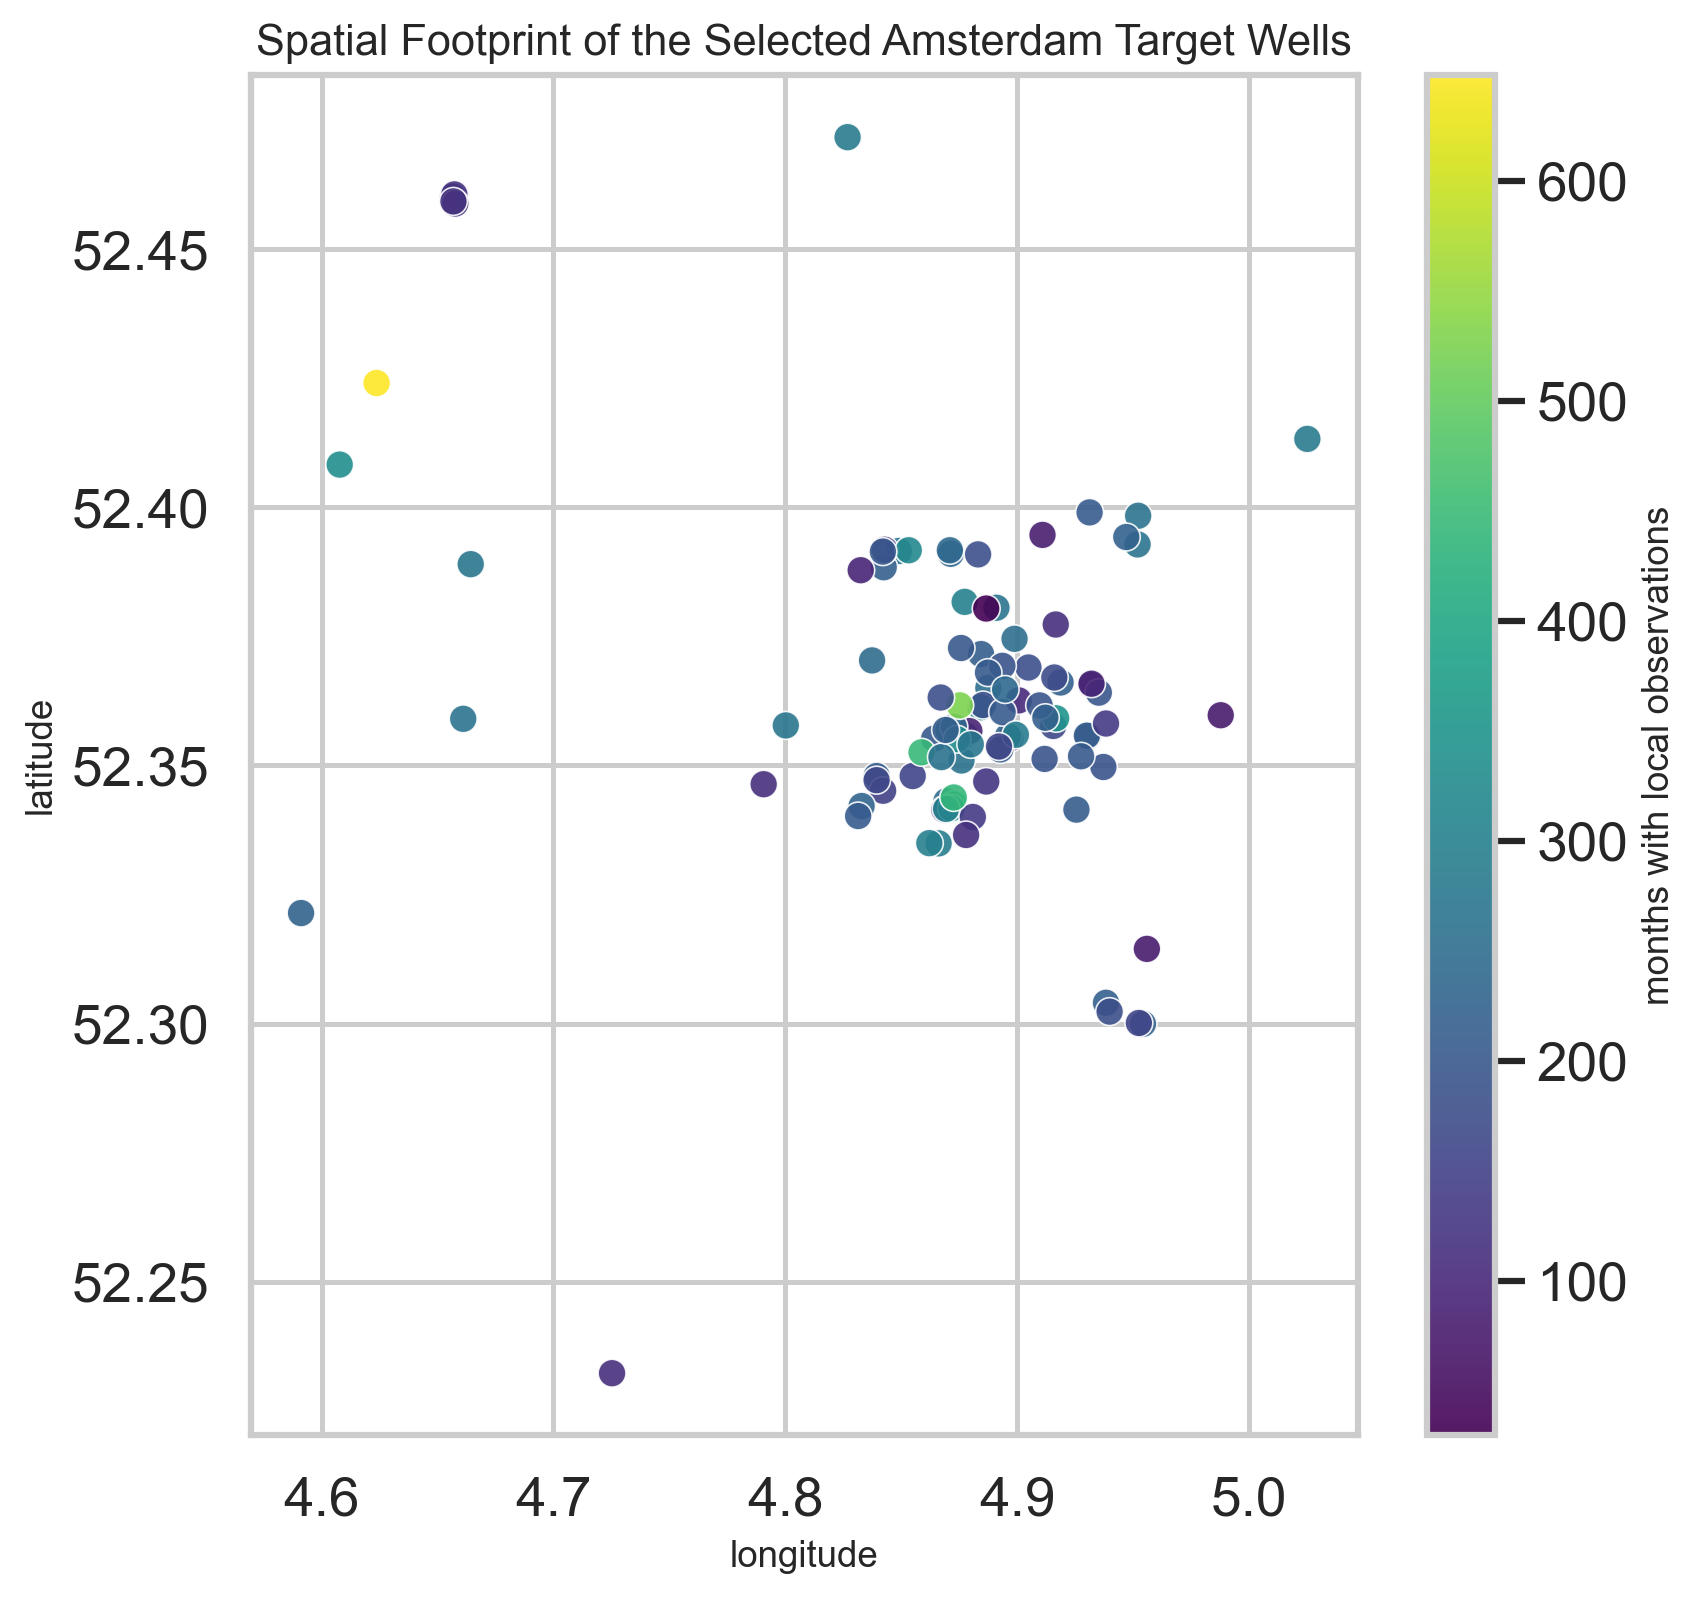

In [22]:
map_df = target_sites.merge(local_coverage[['site_id', 'n_months']], on='site_id', how='left')
map_df['n_months'] = map_df['n_months'].fillna(0)

fig, ax = plt.subplots(figsize=(7.4, 7.0))
sc = ax.scatter(
    map_df['lon'],
    map_df['lat'],
    c=map_df['n_months'],
    cmap='viridis',
    s=70,
    alpha=0.9,
    edgecolor='white',
    linewidth=0.5,
)
cb = fig.colorbar(sc, ax=ax)
cb.set_label('months with local observations')
ax.set_title('Spatial Footprint of the Selected Amsterdam Target Wells')
ax.set_xlabel('longitude')
ax.set_ylabel('latitude')
plt.tight_layout()
save_and_show(fig, 'target_sites_map.png')


Saved: /Users/izhan/Desktop/groundwater/stephanie_thesis_groundwater/Data/processed/figures_eda/target_site_coverage_distribution.png


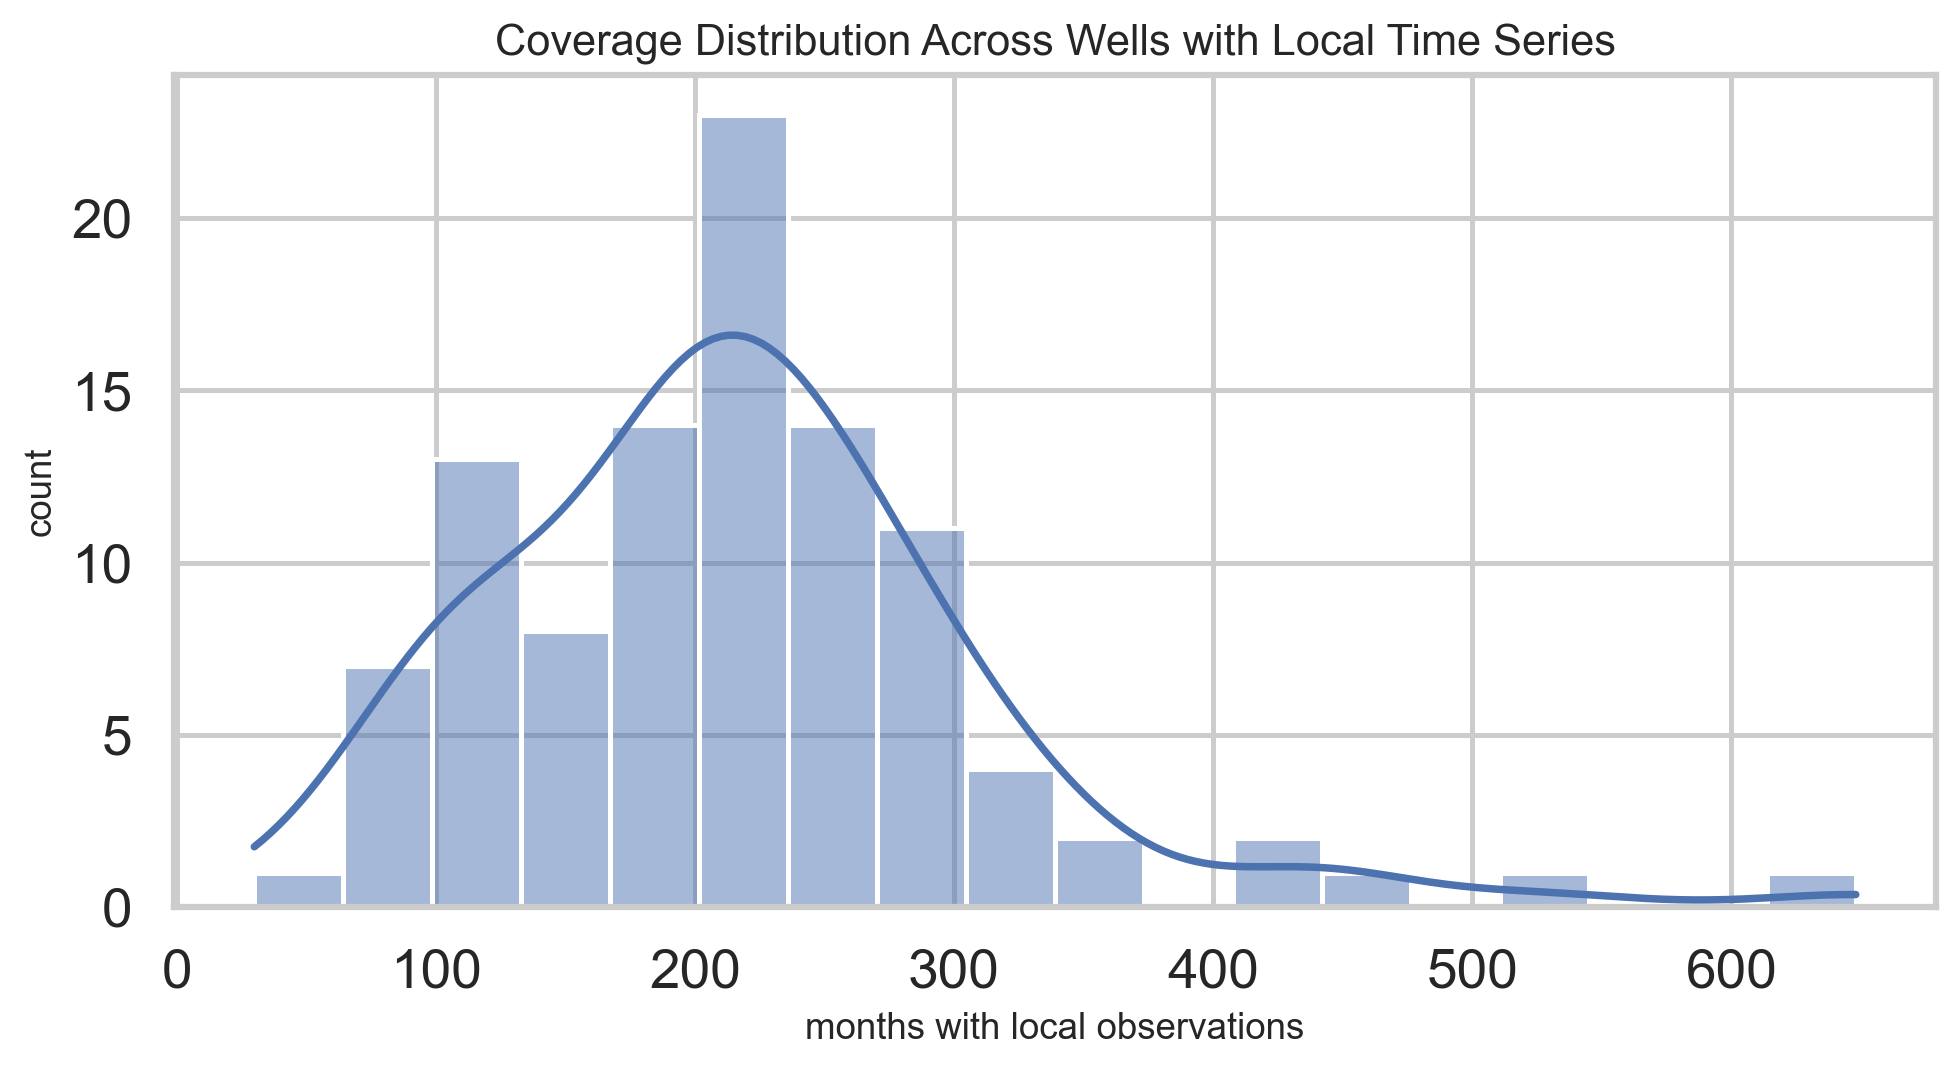

In [23]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
sns.histplot(local_coverage['n_months'], bins=18, color='#4c72b0', kde=True, ax=ax)
ax.set_title('Coverage Distribution Across Wells with Local Time Series')
ax.set_xlabel('months with local observations')
ax.set_ylabel('count')
plt.tight_layout()
save_and_show(fig, 'target_site_coverage_distribution.png')


## Univariate Analysis

I next inspect the target-variable panel itself. I want to see missingness, distribution shape, and seasonal behaviour before I interpret any model results.


In [24]:
feature_missingness


,feature,missing_share,non_missing_n
0,wtda,0.0,11508
1,water_level_nap_m,0.0,11508
2,tsmp_wtda,0.0,11508
3,pr_a,0.0,11508
4,sm_a,0.0,11508


Saved: /Users/izhan/Desktop/groundwater/stephanie_thesis_groundwater/Data/processed/figures_eda/feature_missingness_share.png


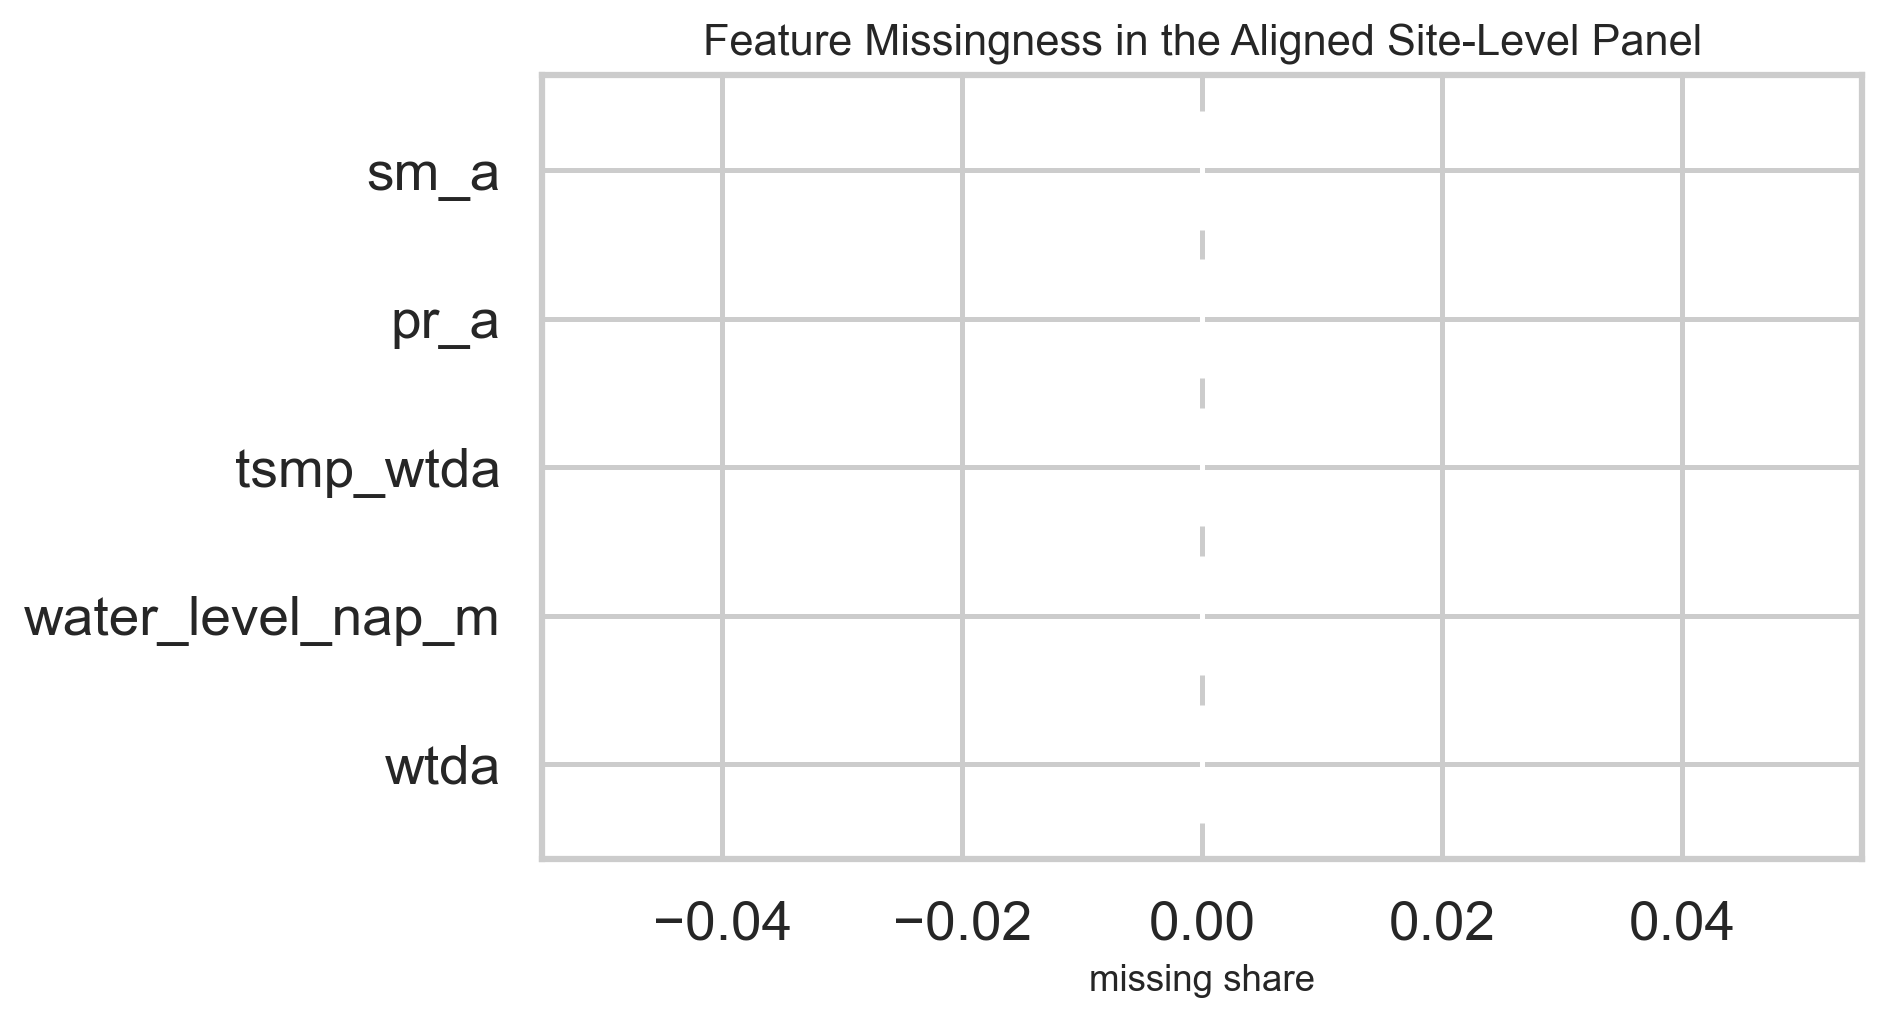

In [25]:
fig, ax = plt.subplots(figsize=(8.2, 4.6))
show = feature_missingness.sort_values('missing_share', ascending=False)
ax.barh(show['feature'], show['missing_share'], color='#f4a261')
ax.set_title('Feature Missingness in the Aligned Site-Level Panel')
ax.set_xlabel('missing share')
ax.set_ylabel('')
plt.tight_layout()
save_and_show(fig, 'feature_missingness_share.png')


I do not treat the clean aligned panel as proof that the raw data are inherently clean. It only means that the filtering and alignment steps worked as intended for the final modelling table.


In [26]:
monthly_local['wtda'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(3)


count    22102.000
mean        -0.006
std          1.550
min        -18.699
25%         -0.684
50%          0.023
75%          0.729
90%          1.492
95%          2.163
99%          4.166
max         14.896
Name: wtda, dtype: float64

Saved: /Users/izhan/Desktop/groundwater/stephanie_thesis_groundwater/Data/processed/figures_eda/local_wtda_distribution.png


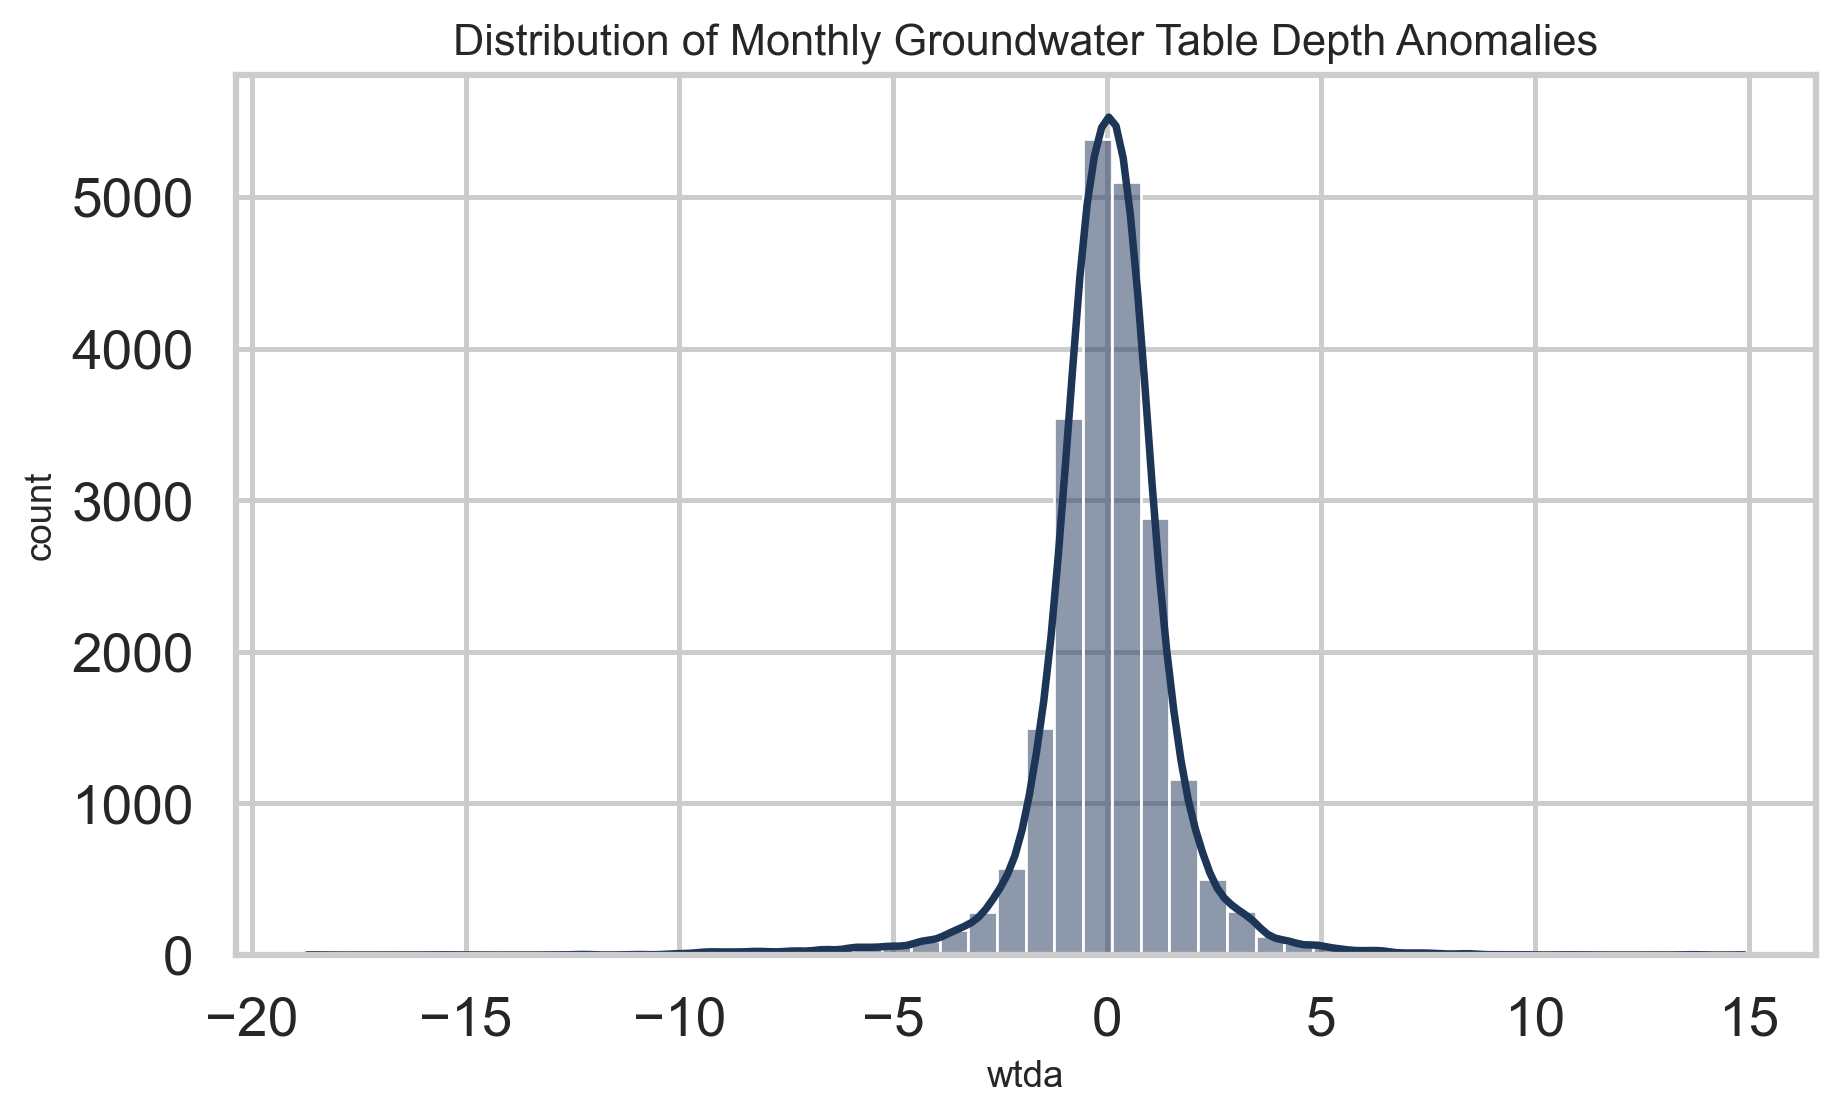

In [27]:
fig, ax = plt.subplots(figsize=(8.0, 5.0))
sns.histplot(monthly_local['wtda'].dropna(), bins=50, kde=True, color='#1d3557', ax=ax)
ax.set_title('Distribution of Monthly Groundwater Table Depth Anomalies')
ax.set_xlabel('wtda')
ax.set_ylabel('count')
plt.tight_layout()
save_and_show(fig, 'local_wtda_distribution.png')


I keep the strong negative extremes visible. In my thesis setting, these events can be hydrologically meaningful rather than simple outliers.


## Seasonal Patterns

I also check whether the monthly anomaly distribution changes across the calendar year.


Saved: /Users/izhan/Desktop/groundwater/stephanie_thesis_groundwater/Data/processed/figures_eda/seasonal_wtda_boxplot.png


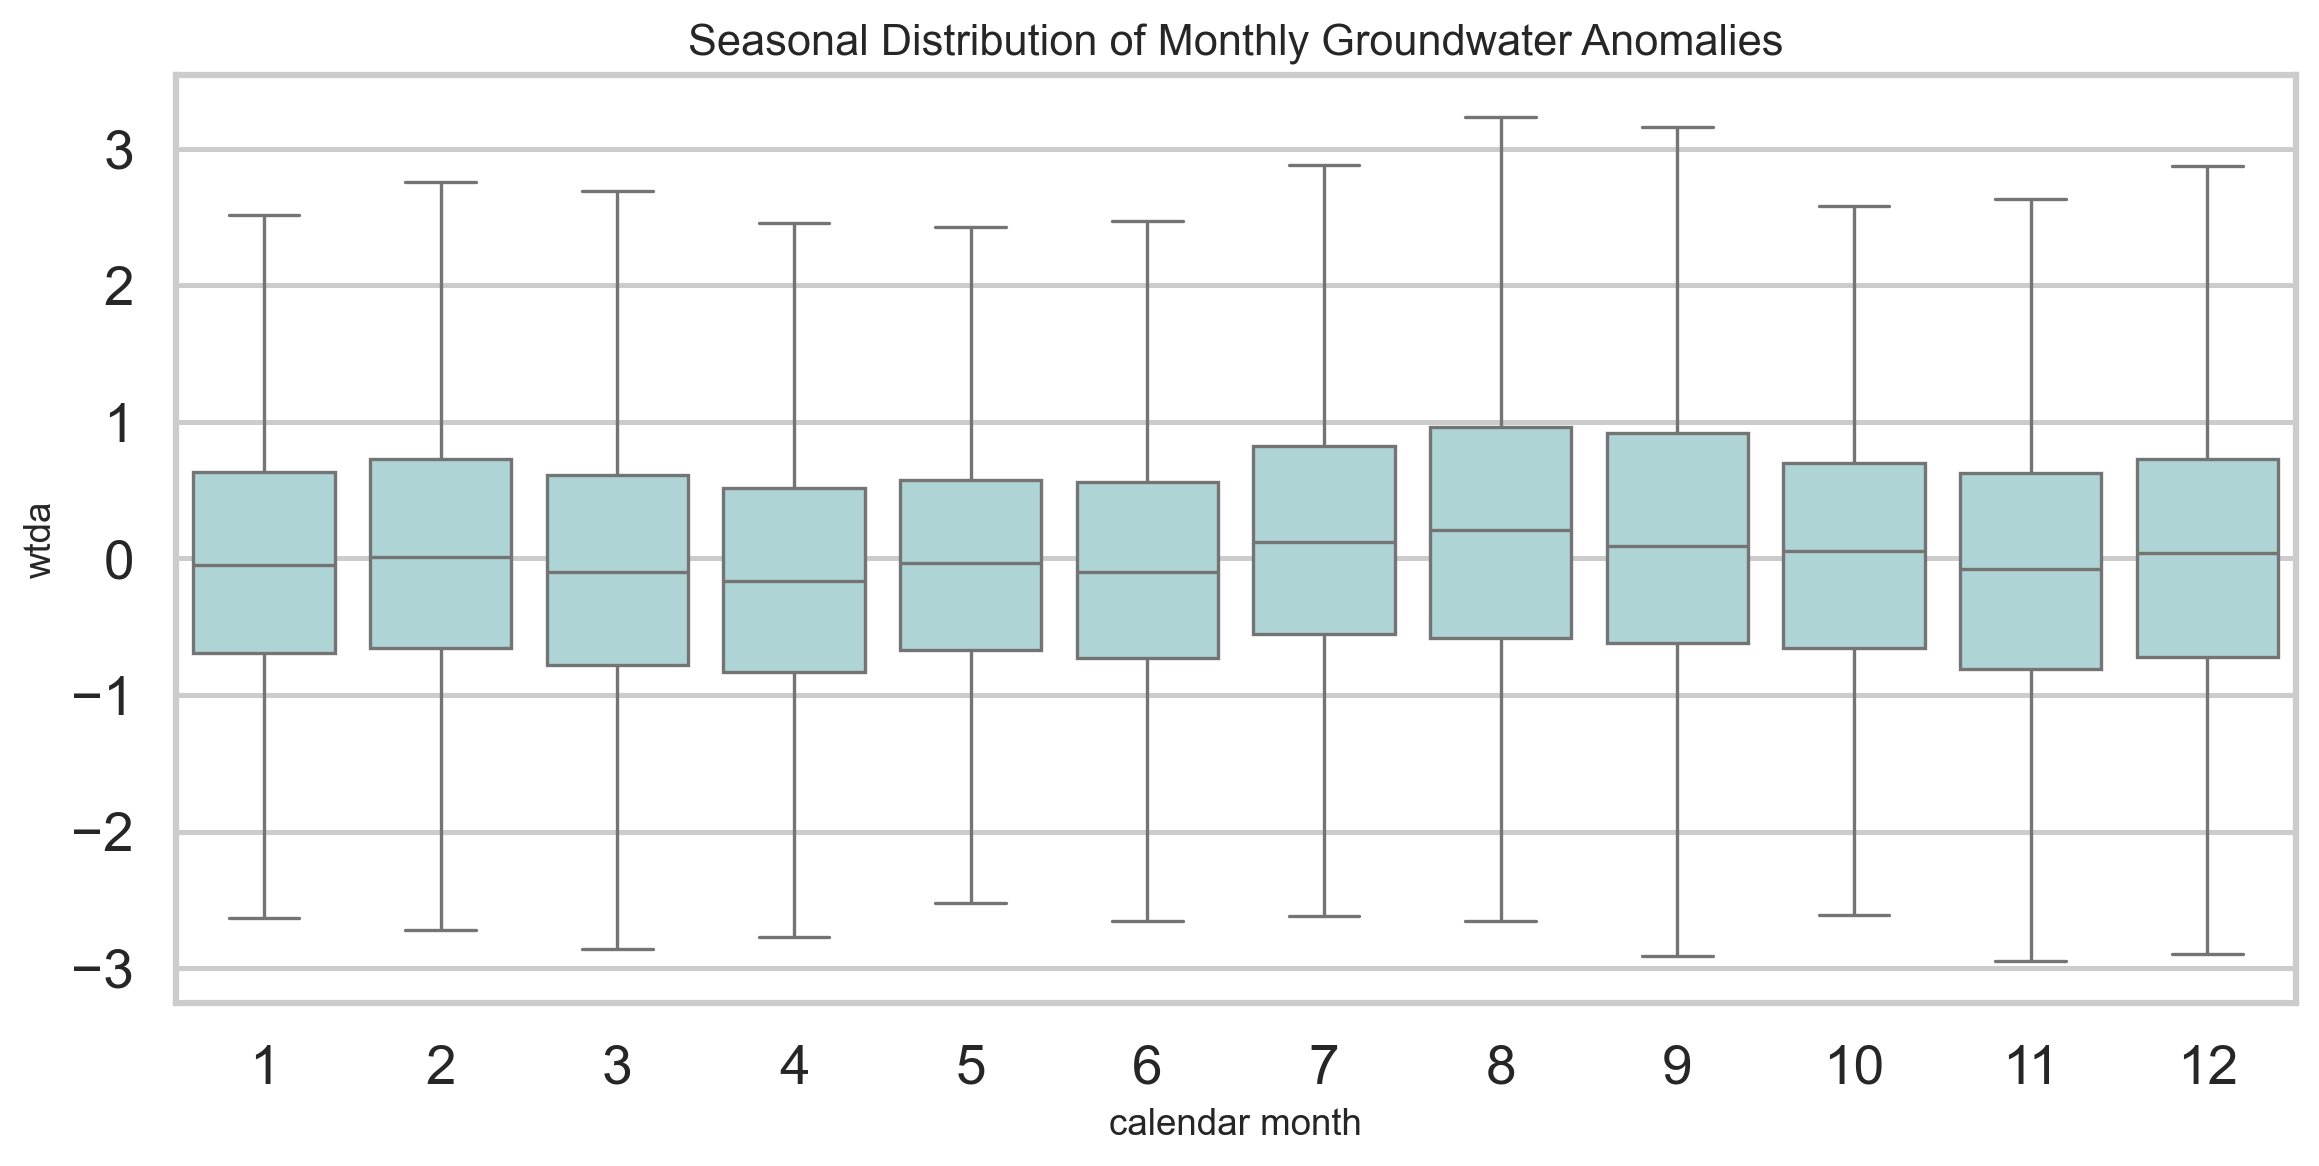

In [28]:
season_df = site_panel[['month', 'wtda']].dropna().copy()
season_df['month_num'] = season_df['month'].dt.month

fig, ax = plt.subplots(figsize=(10.0, 5.2))
sns.boxplot(data=season_df, x='month_num', y='wtda', color='#a8dadc', showfliers=False, ax=ax)
ax.set_title('Seasonal Distribution of Monthly Groundwater Anomalies')
ax.set_xlabel('calendar month')
ax.set_ylabel('wtda')
plt.tight_layout()
save_and_show(fig, 'seasonal_wtda_boxplot.png')


# Combined Dataset for Correlation Analysis

I now combine the local groundwater panel with the climate drivers so that I can inspect broad relationships before I move to site-level heterogeneity.


In [29]:
monthly_driver = (
    site_panel.groupby('month', as_index=False)[['wtda', 'tsmp_wtda', 'pr_a', 'sm_a']]
    .mean()
    .rename(columns={'wtda': 'local_mean_wtda'})
)

monthly_driver[['local_mean_wtda', 'tsmp_wtda', 'pr_a', 'sm_a']].corr().round(3)


,local_mean_wtda,tsmp_wtda,pr_a,sm_a
local_mean_wtda,1.000,-0.163,0.054,0.075
tsmp_wtda,-0.163,1.000,-0.070,-0.326
pr_a,0.054,-0.070,1.000,0.047
sm_a,0.075,-0.326,0.047,1.000


Saved: /Users/izhan/Desktop/groundwater/stephanie_thesis_groundwater/Data/processed/figures_eda/standardized_monthly_signals.png


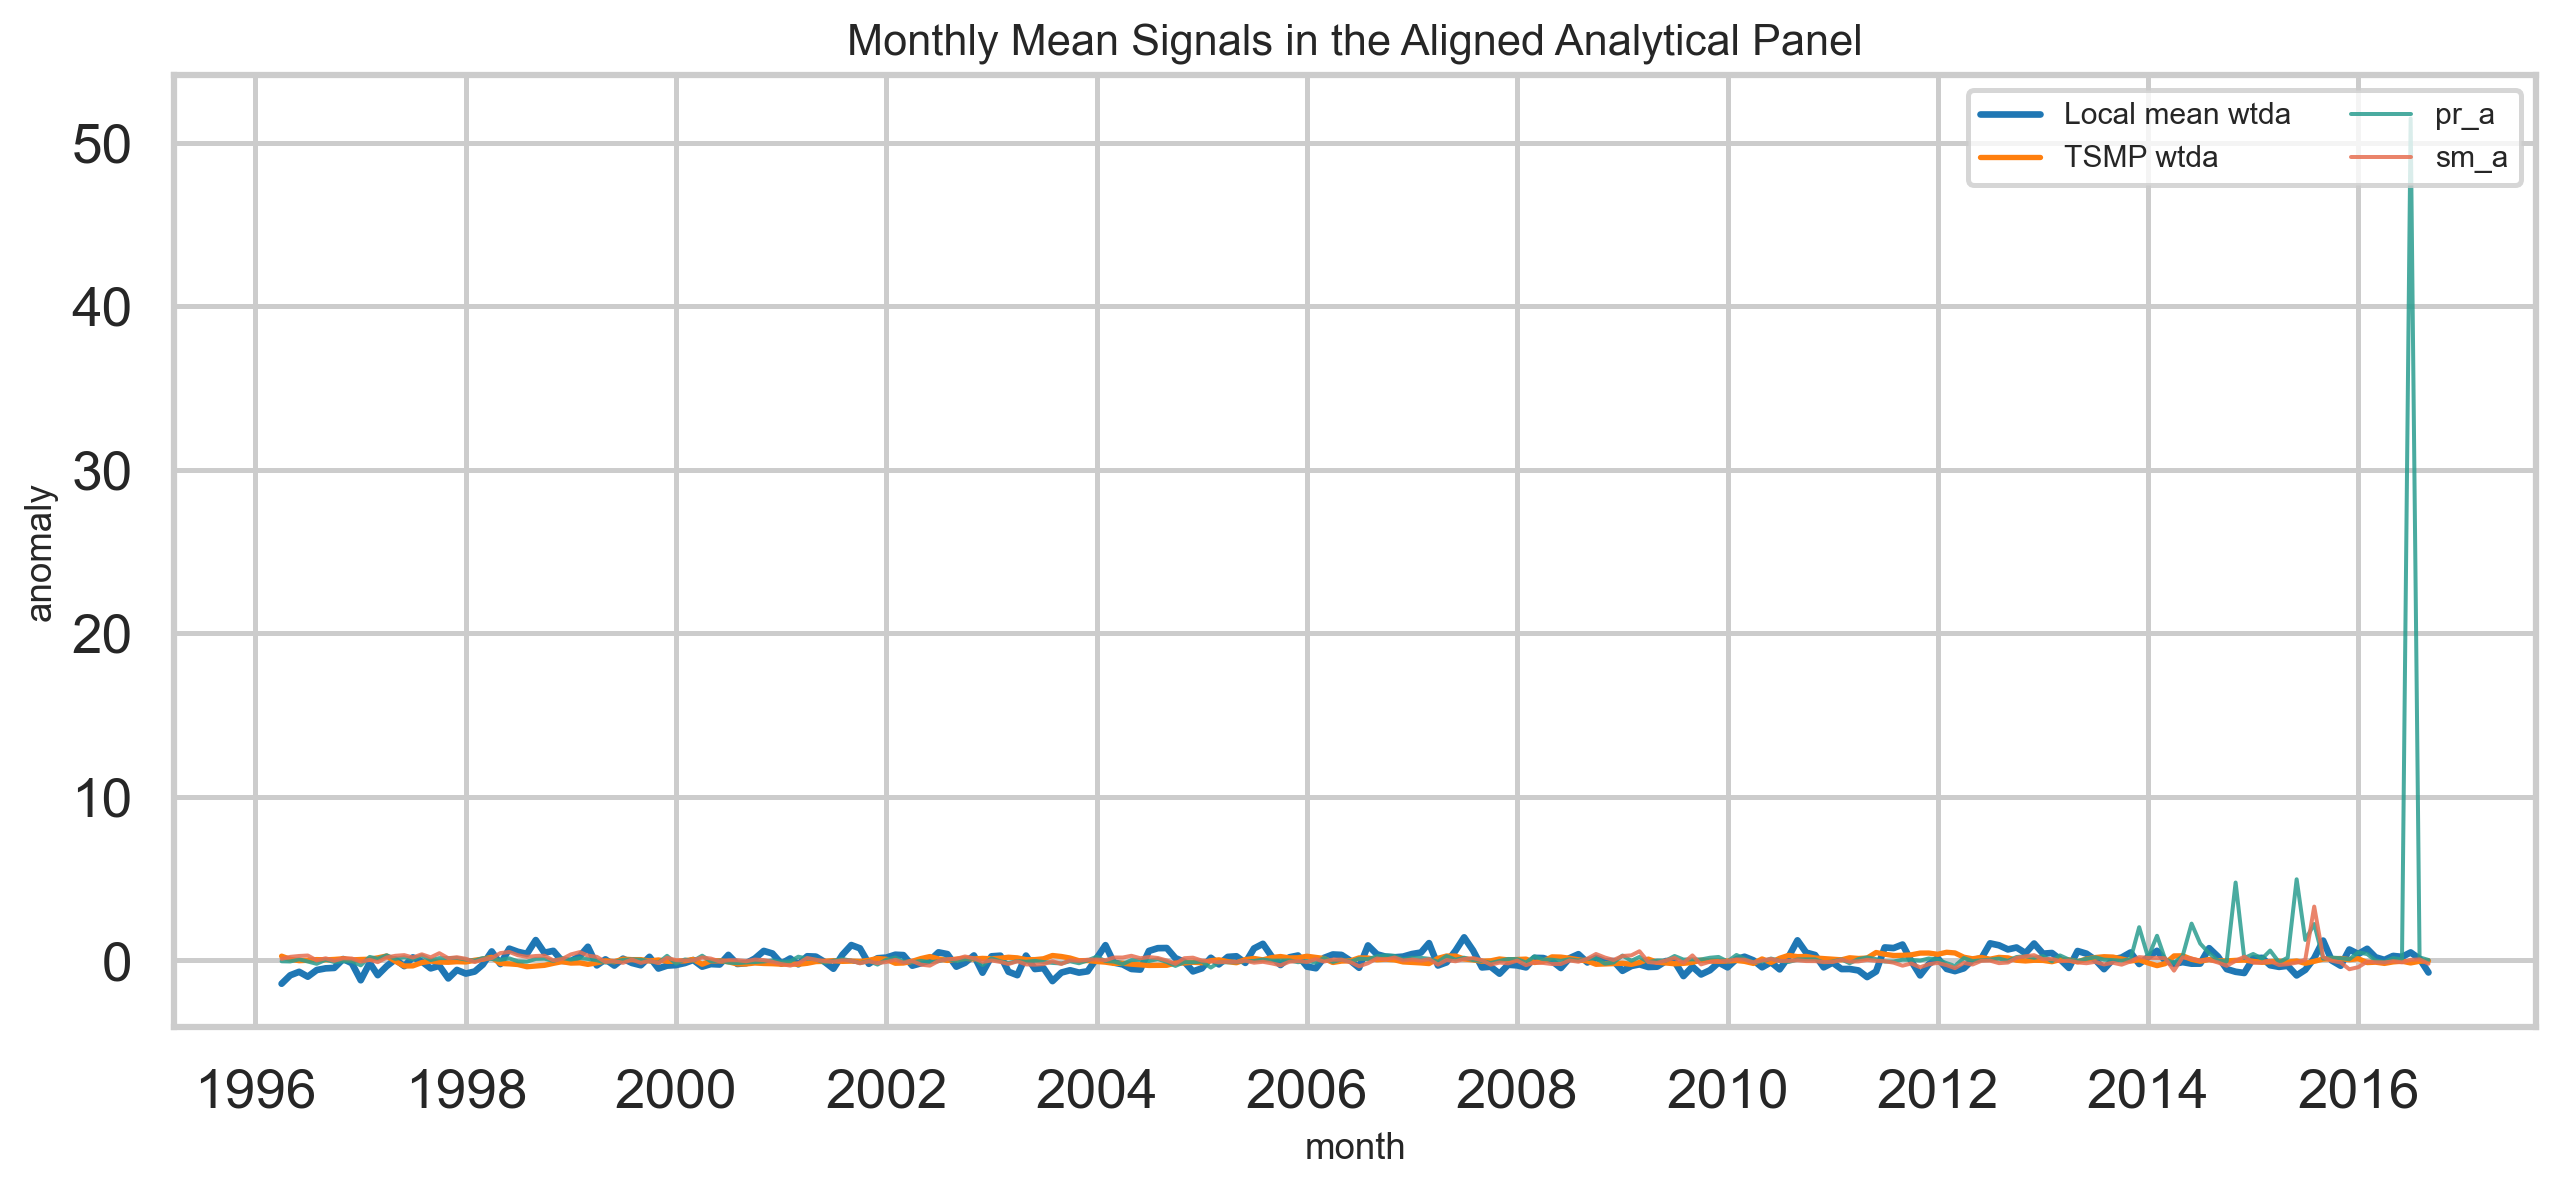

In [30]:
fig, ax = plt.subplots(figsize=(11.0, 5.3))
ax.plot(monthly_driver['month'], monthly_driver['local_mean_wtda'], label='Local mean wtda', color='#1f77b4', lw=2)
ax.plot(monthly_driver['month'], monthly_driver['tsmp_wtda'], label='TSMP wtda', color='#ff7f0e', lw=1.6)
ax.plot(monthly_driver['month'], monthly_driver['pr_a'], label='pr_a', color='#2a9d8f', lw=1.2, alpha=0.85)
ax.plot(monthly_driver['month'], monthly_driver['sm_a'], label='sm_a', color='#e76f51', lw=1.2, alpha=0.85)
ax.set_title('Monthly Mean Signals in the Aligned Analytical Panel')
ax.set_xlabel('month')
ax.set_ylabel('anomaly')
ax.legend(loc='upper right', ncol=2)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
save_and_show(fig, 'standardized_monthly_signals.png')


Saved: /Users/izhan/Desktop/groundwater/stephanie_thesis_groundwater/Data/processed/figures_eda/lagged_correlation_heatmap.png


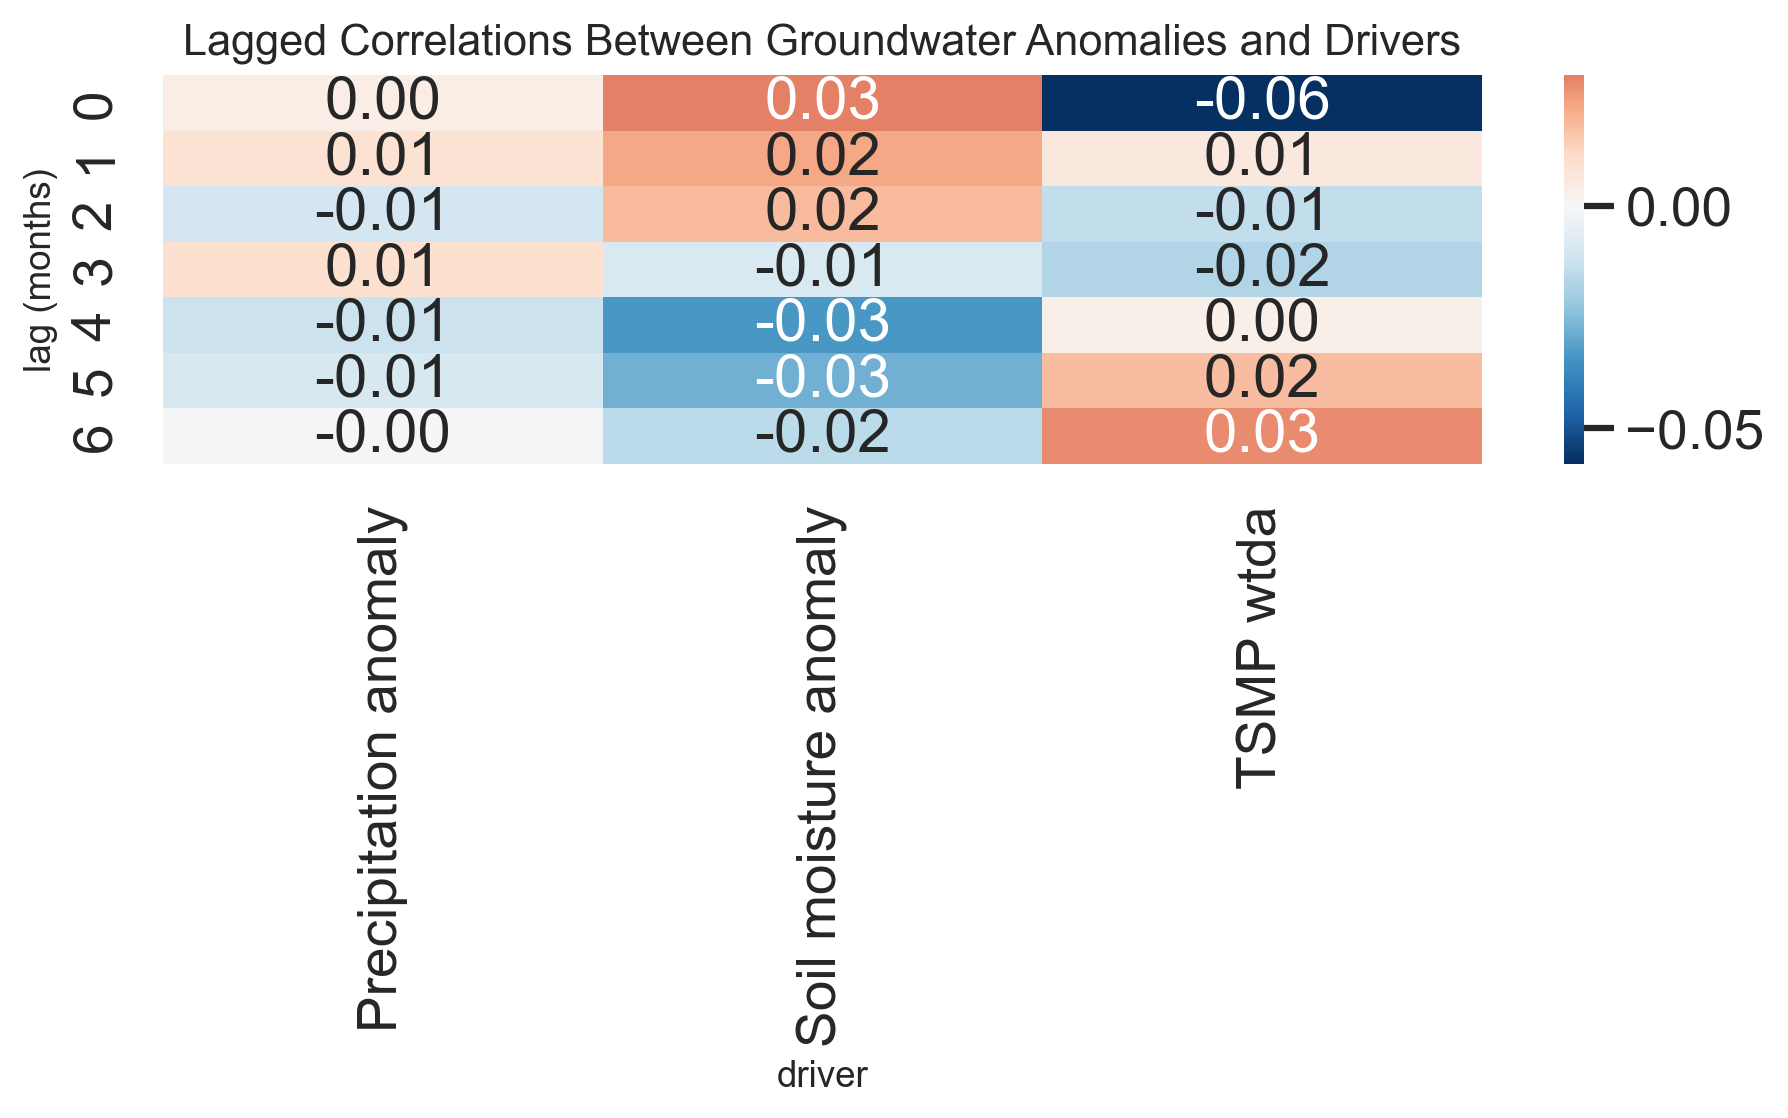

In [31]:
lag_heat = pooled_lag.pivot(index='lag', columns='driver', values='corr').sort_index()

fig, ax = plt.subplots(figsize=(8.0, 5.0))
sns.heatmap(lag_heat, annot=True, fmt='.2f', cmap='RdBu_r', center=0.0, ax=ax)
ax.set_title('Lagged Correlations Between Groundwater Anomalies and Drivers')
ax.set_xlabel('driver')
ax.set_ylabel('lag (months)')
plt.tight_layout()
save_and_show(fig, 'lagged_correlation_heatmap.png')


I use these pooled correlations as a first signal, not as my final conclusion. I still need to check whether these relationships change from one site to another.


## Site-Level Heterogeneity

In this section, I look at how much the driver response varies across wells.


In [32]:
best_lags.groupby('driver')['corr'].agg(['count', 'median', 'min', 'max']).round(3)


,count,median,min,max
driver,,,,
Precipitation anomaly,102,0.099,-0.379,0.610
Soil moisture anomaly,102,0.098,-0.461,0.402
TSMP wtda,102,-0.058,-0.582,0.405


Saved: /Users/izhan/Desktop/groundwater/stephanie_thesis_groundwater/Data/processed/figures_eda/site_heterogeneity_correlation_heatmap.png


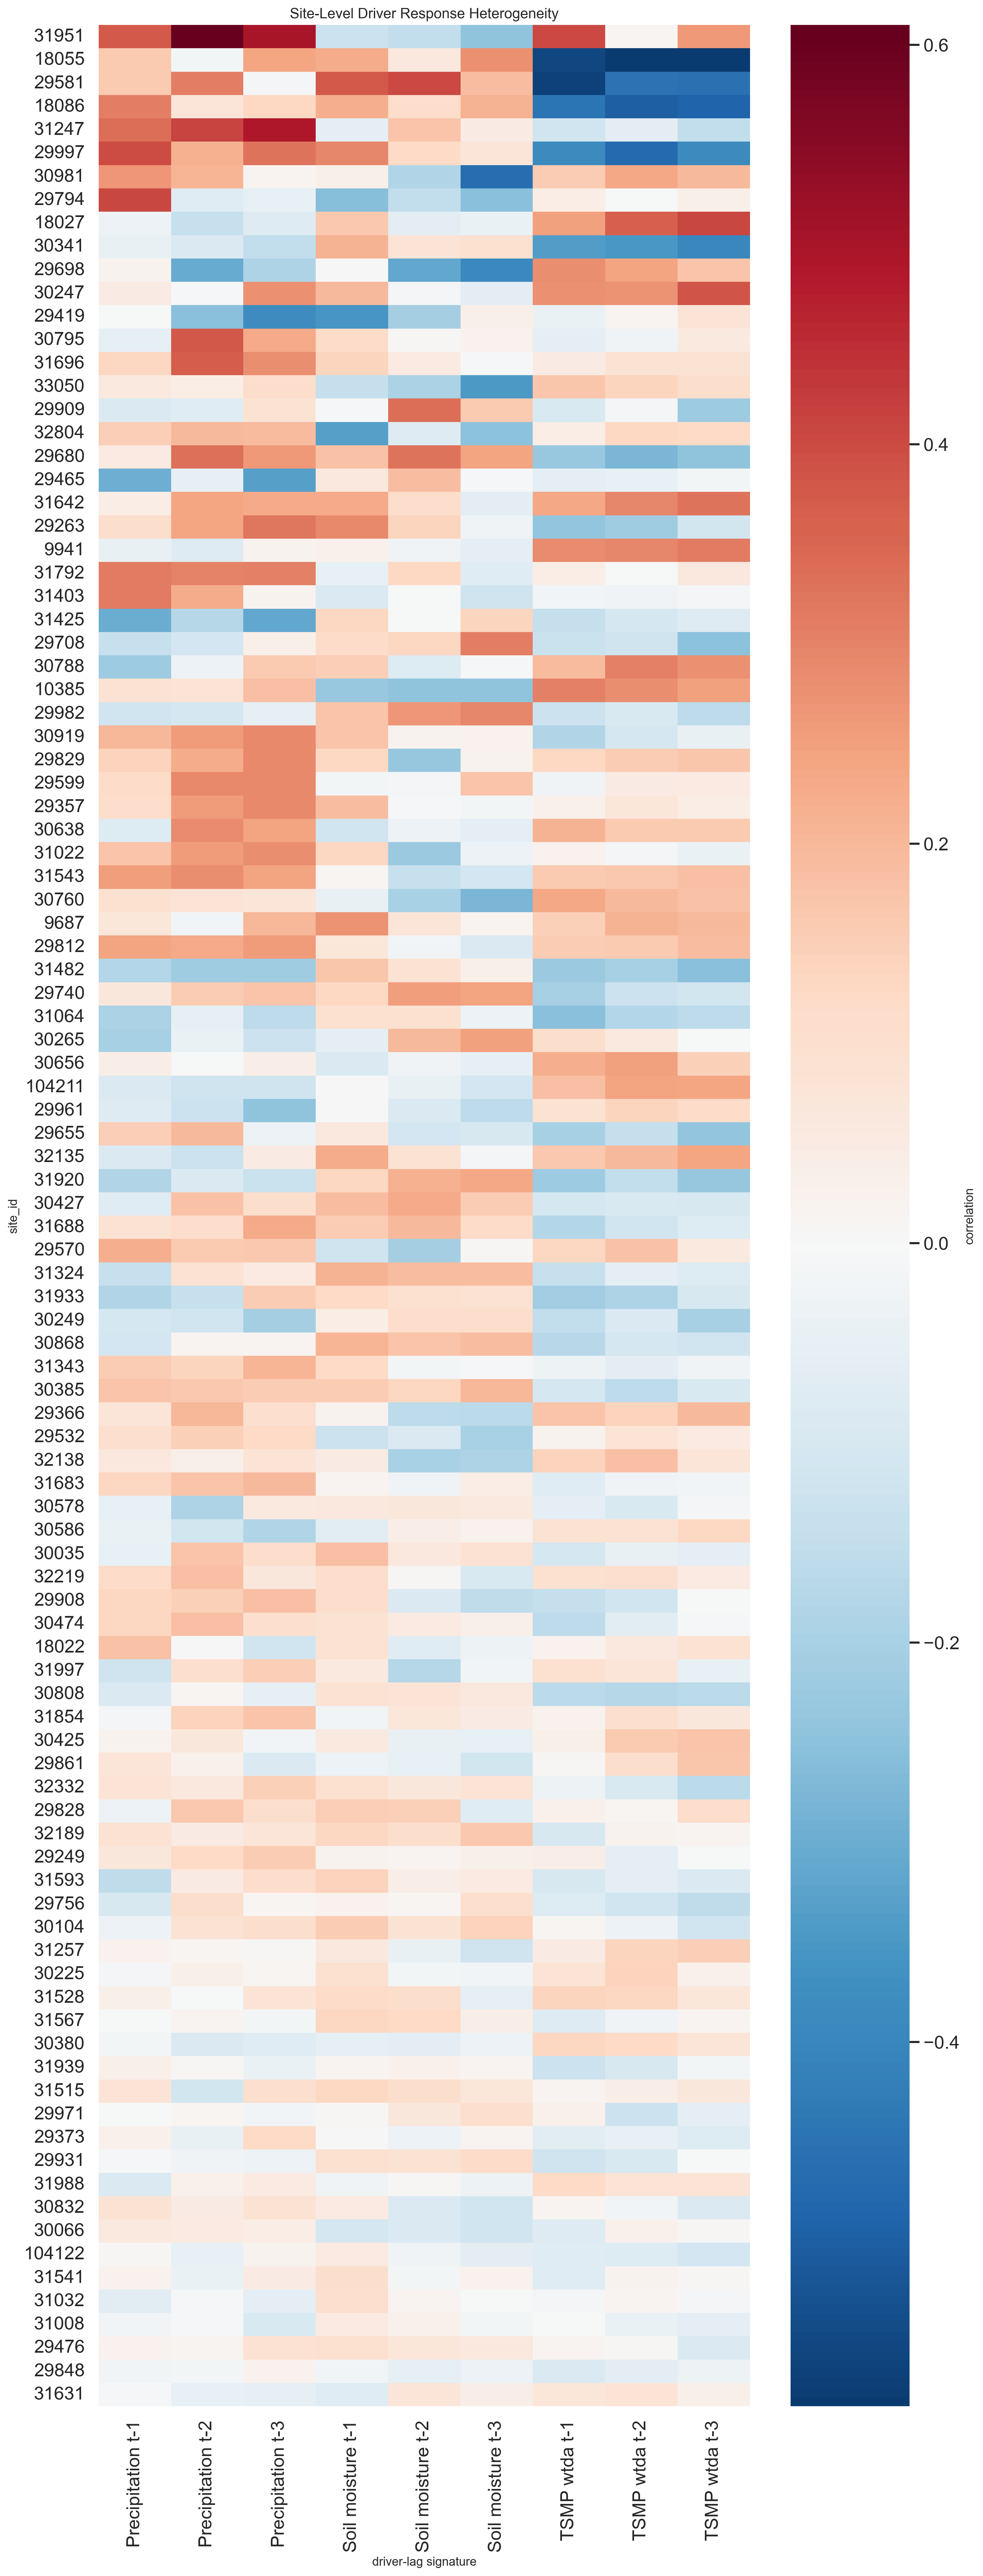

In [33]:
site_heat = site_lag.copy()
site_heat['driver_lag'] = site_heat['driver'].str.replace(' anomaly', '', regex=False) + ' t-' + site_heat['lag'].astype(str)
heat = site_heat.pivot(index='site_id', columns='driver_lag', values='corr')
order = site_heat.groupby('site_id')['corr'].apply(lambda s: s.abs().max(skipna=True)).sort_values(ascending=False).index
heat = heat.loc[order]

fig_height = max(7.0, 0.32 * len(heat))
fig, ax = plt.subplots(figsize=(12.5, fig_height))
sns.heatmap(heat, cmap='RdBu_r', center=0.0, ax=ax, cbar_kws={'label': 'correlation'})
ax.set_title('Site-Level Driver Response Heterogeneity')
ax.set_xlabel('driver-lag signature')
ax.set_ylabel('site_id')
plt.tight_layout()
save_and_show(fig, 'site_heterogeneity_correlation_heatmap.png')


I also inspect a few representative wells directly so that the heterogeneity is visible in the time series, not only in a summary heatmap.


Saved: /Users/izhan/Desktop/groundwater/stephanie_thesis_groundwater/Data/processed/figures_eda/representative_well_timeseries.png


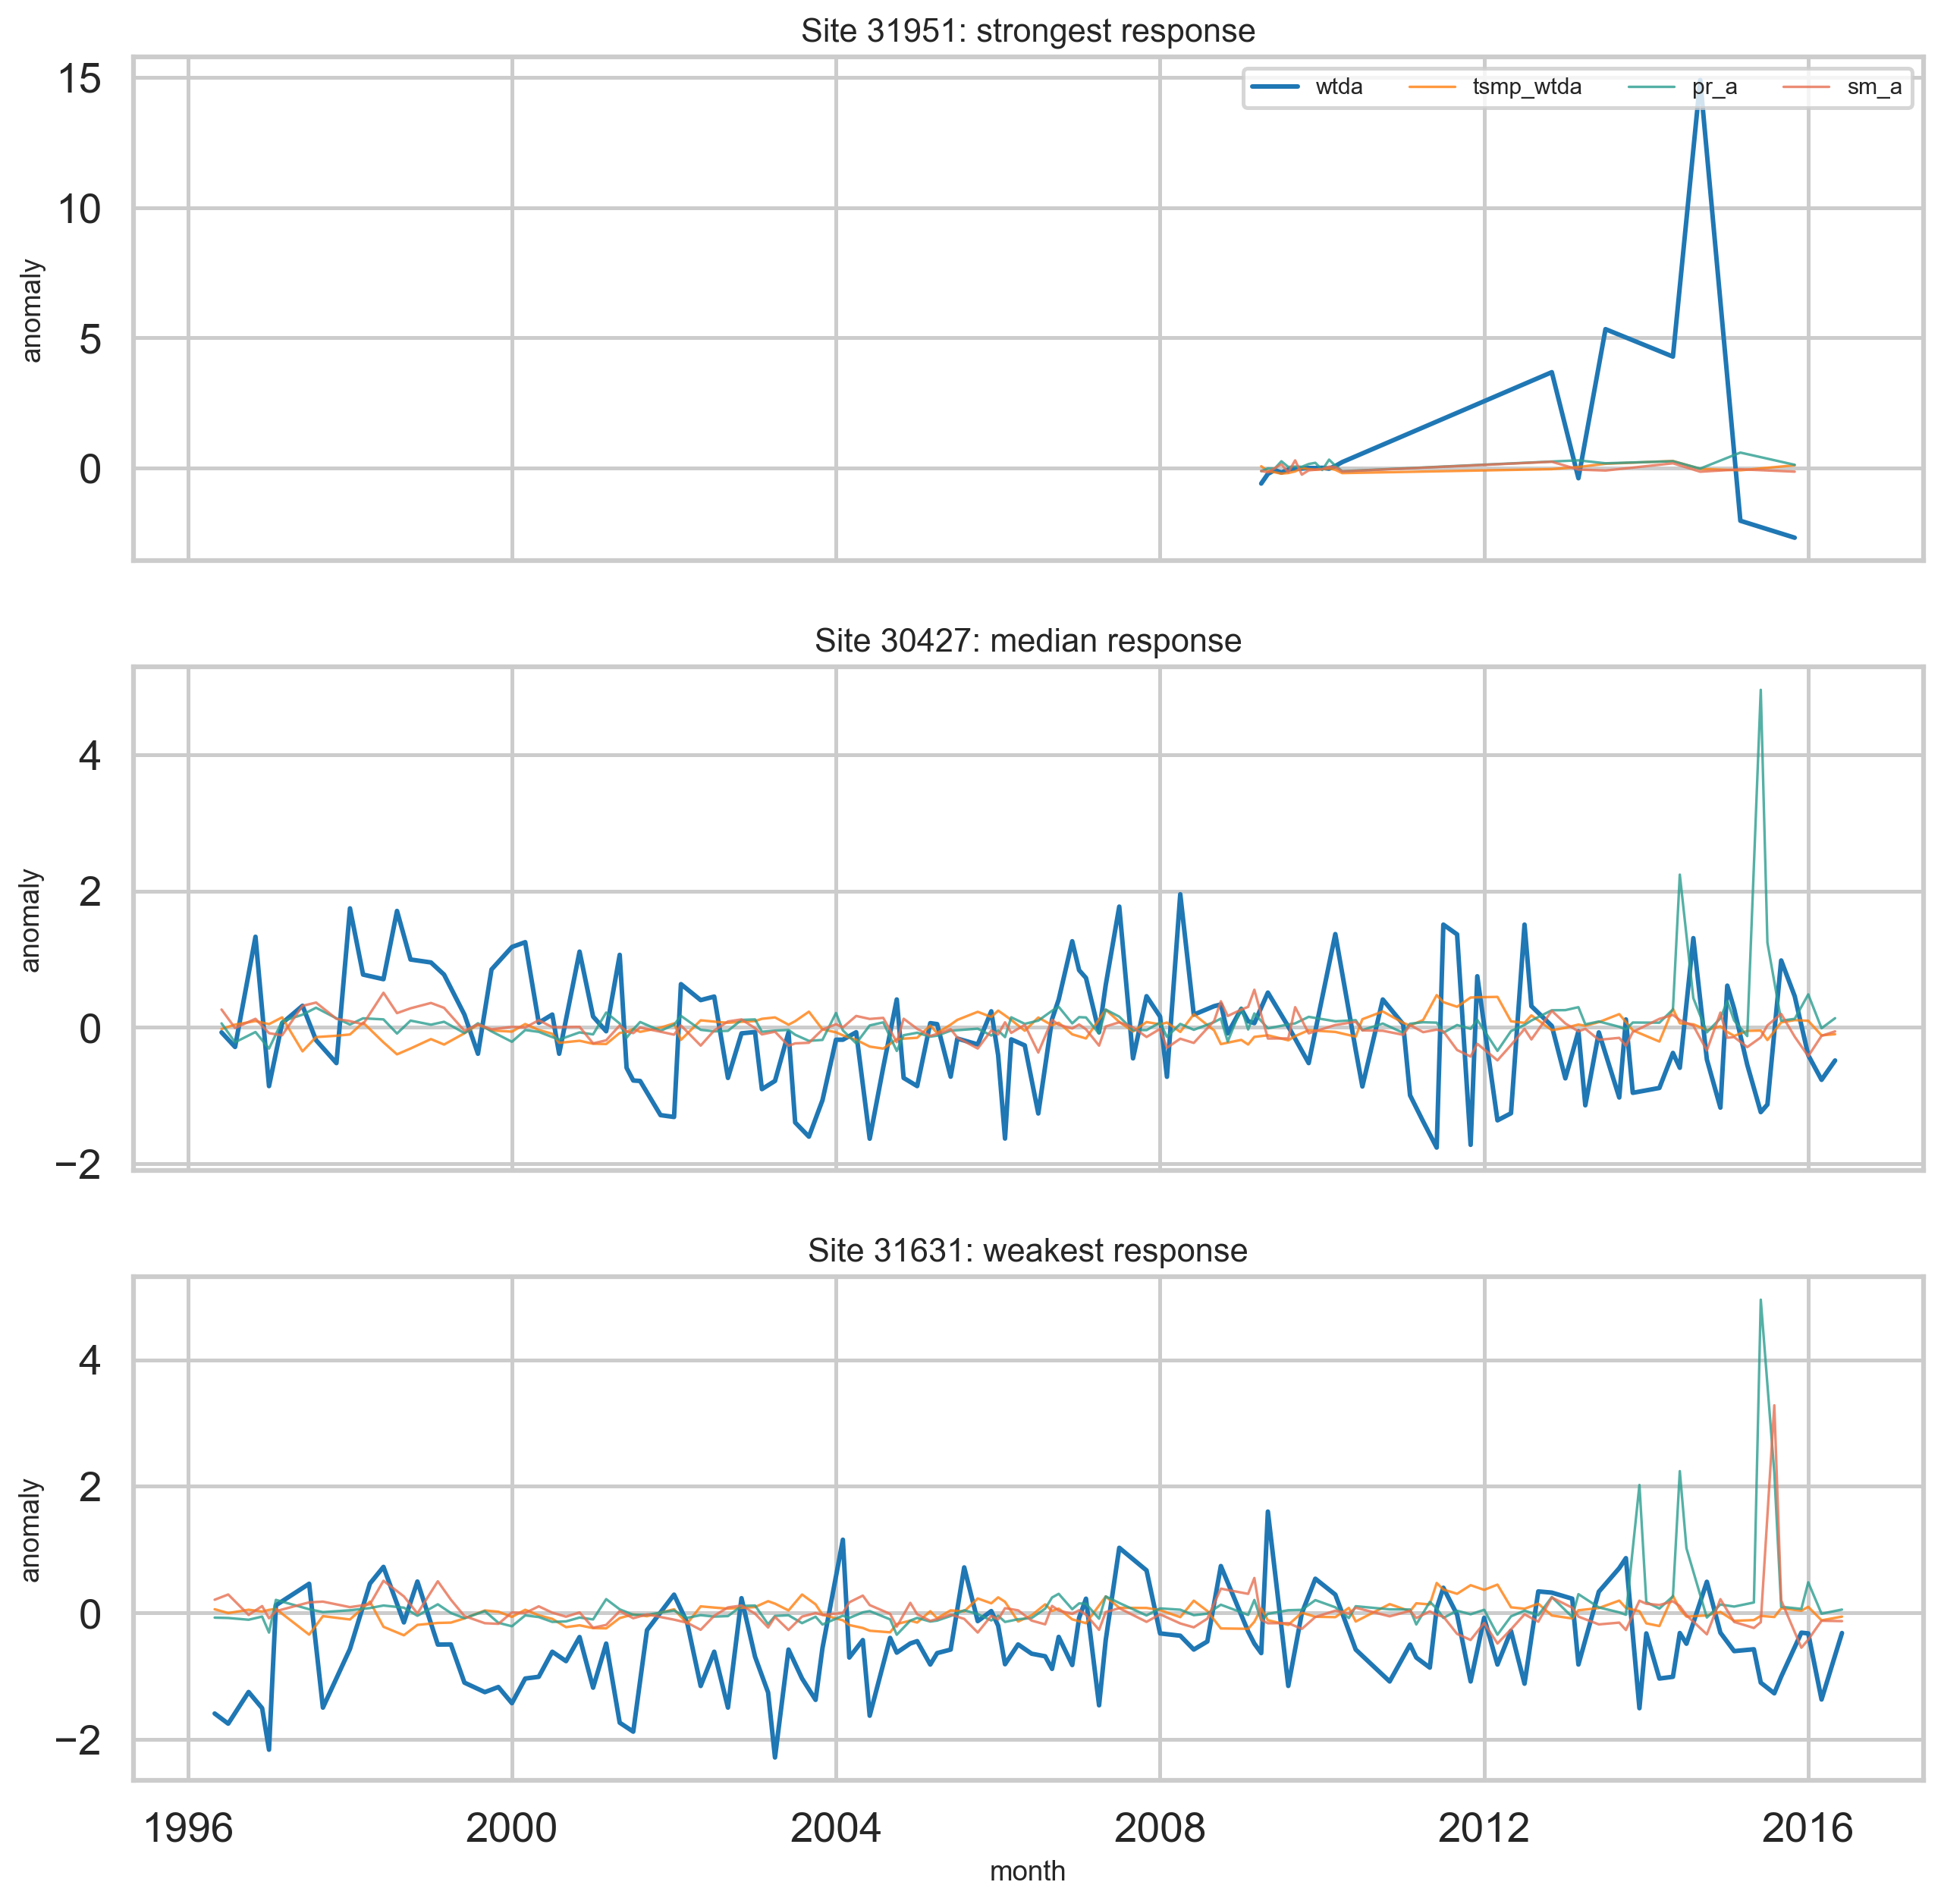

In [34]:
strength = site_lag.groupby('site_id')['corr'].apply(lambda s: s.abs().max(skipna=True)).sort_values()
example_sites = [int(strength.index[-1]), int(strength.index[len(strength) // 2]), int(strength.index[0])]
example_labels = ['strongest response', 'median response', 'weakest response']

fig, axes = plt.subplots(len(example_sites), 1, figsize=(11, 3.6 * len(example_sites)), sharex=True)
if len(example_sites) == 1:
    axes = [axes]

for ax, site_id, label in zip(axes, example_sites, example_labels):
    g = site_panel[site_panel['site_id'] == site_id].sort_values('month').copy()
    ax.plot(g['month'], g['wtda'], label='wtda', color='#1f77b4', lw=1.8)
    ax.plot(g['month'], g['tsmp_wtda'], label='tsmp_wtda', color='#ff7f0e', lw=1.0, alpha=0.8)
    ax.plot(g['month'], g['pr_a'], label='pr_a', color='#2a9d8f', lw=1.0, alpha=0.8)
    ax.plot(g['month'], g['sm_a'], label='sm_a', color='#e76f51', lw=1.0, alpha=0.8)
    ax.set_title(f'Site {site_id}: {label}')
    ax.set_ylabel('anomaly')

axes[0].legend(loc='upper right', ncol=4)
axes[-1].set_xlabel('month')
axes[-1].xaxis.set_major_locator(mdates.YearLocator(4))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
save_and_show(fig, 'representative_well_timeseries.png')


The representative wells show that I should not assume one global transfer pattern for all sites. This is one reason why selective transfer becomes interesting later in the thesis.


# Dataset Timeline Visualization

I next compare the time coverage of the target panel and the source panel.


Saved: /Users/izhan/Desktop/groundwater/stephanie_thesis_groundwater/Data/processed/figures_eda/dataset_coverage_timeline.png


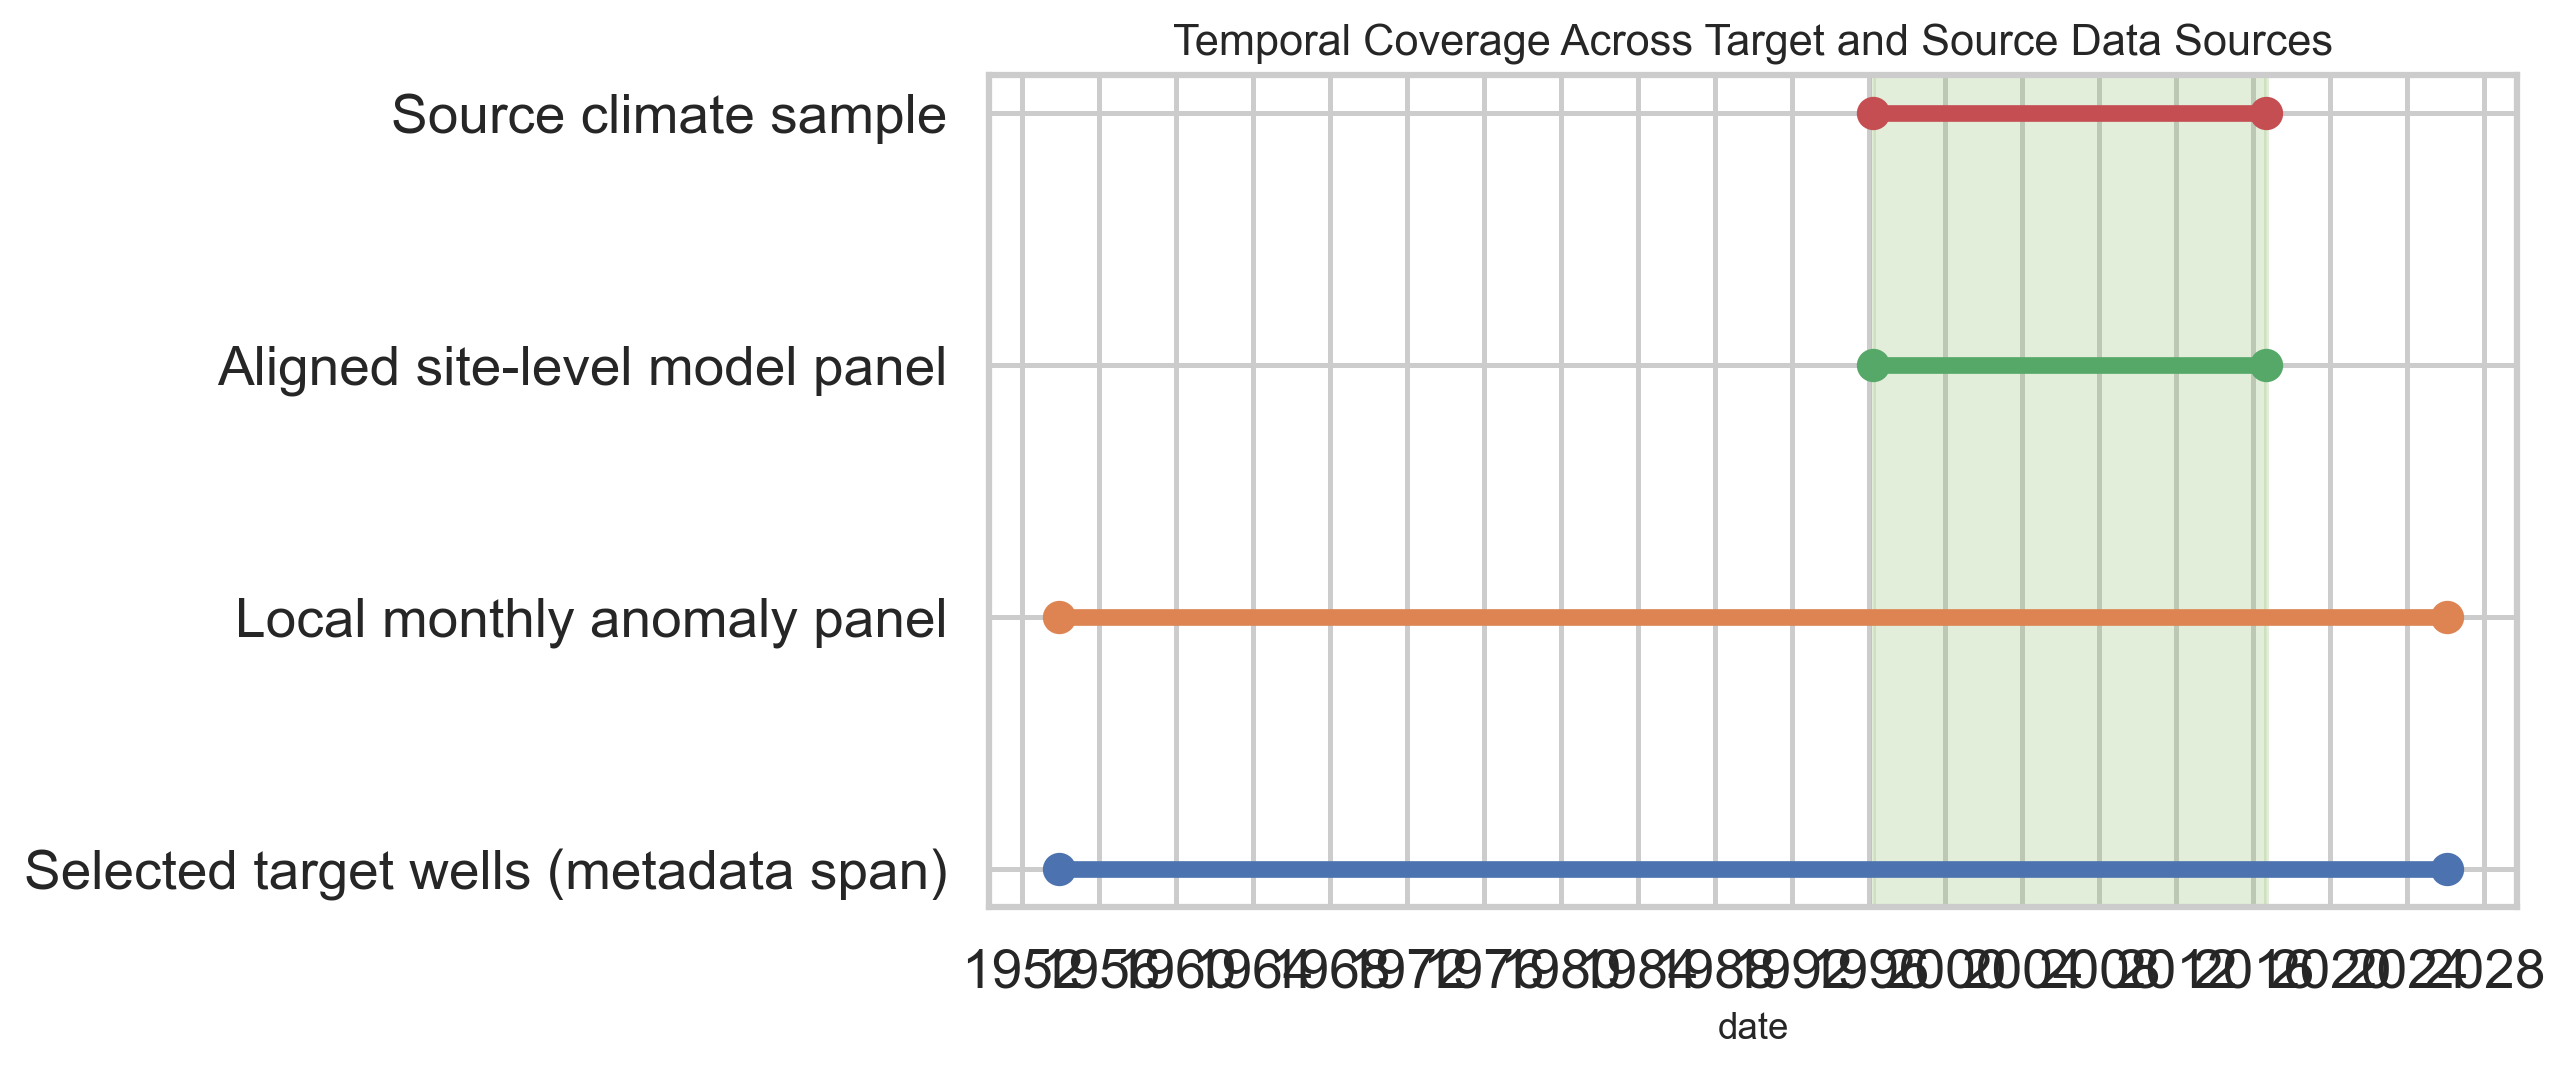

In [35]:
ranges = [
    ('Selected target wells (metadata span)', target_sites['first_date'].min(), target_sites['last_date'].max()),
    ('Local monthly anomaly panel', monthly_local['month'].min(), monthly_local['month'].max()),
    ('Aligned site-level model panel', site_panel['month'].min(), site_panel['month'].max()),
    ('Source climate sample', source_grid['month'].min(), source_grid['month'].max()),
]

overlap_start = max(start for _, start, _ in ranges)
overlap_end = min(end for _, _, end in ranges)

fig, ax = plt.subplots(figsize=(11.0, 4.8))
for i, (label, start, end) in enumerate(ranges):
    ax.plot([start, end], [i, i], marker='o', lw=5, solid_capstyle='round')
ax.axvspan(overlap_start, overlap_end, color='#90be6d', alpha=0.25)
ax.set_yticks(range(len(ranges)))
ax.set_yticklabels([x[0] for x in ranges])
ax.set_title('Temporal Coverage Across Target and Source Data Sources')
ax.set_xlabel('date')
ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
save_and_show(fig, 'dataset_coverage_timeline.png')


# Source-Target Similarity

In the last part of the EDA, I check whether some source cells look much closer to some target wells than others.


In [36]:
similarity_summary = pd.DataFrame({
    'metric': [
        'pairwise_similarity_median',
        'pairwise_similarity_min',
        'pairwise_similarity_max',
        'best_match_similarity_median',
        'best_match_similarity_min',
        'best_match_similarity_max',
    ],
    'value': [
        similarity_df['cosine_similarity'].median(),
        similarity_df['cosine_similarity'].min(),
        similarity_df['cosine_similarity'].max(),
        best_matches['cosine_similarity'].median(),
        best_matches['cosine_similarity'].min(),
        best_matches['cosine_similarity'].max(),
    ],
})
similarity_summary.round(3)


,metric,value
0,pairwise_similarity_median,0.008
1,pairwise_similarity_min,-0.617
2,pairwise_similarity_max,0.979
3,best_match_similarity_median,0.388
4,best_match_similarity_min,0.168
5,best_match_similarity_max,0.979


Saved: /Users/izhan/Desktop/groundwater/stephanie_thesis_groundwater/Data/processed/figures_eda/source_target_similarity_distribution.png


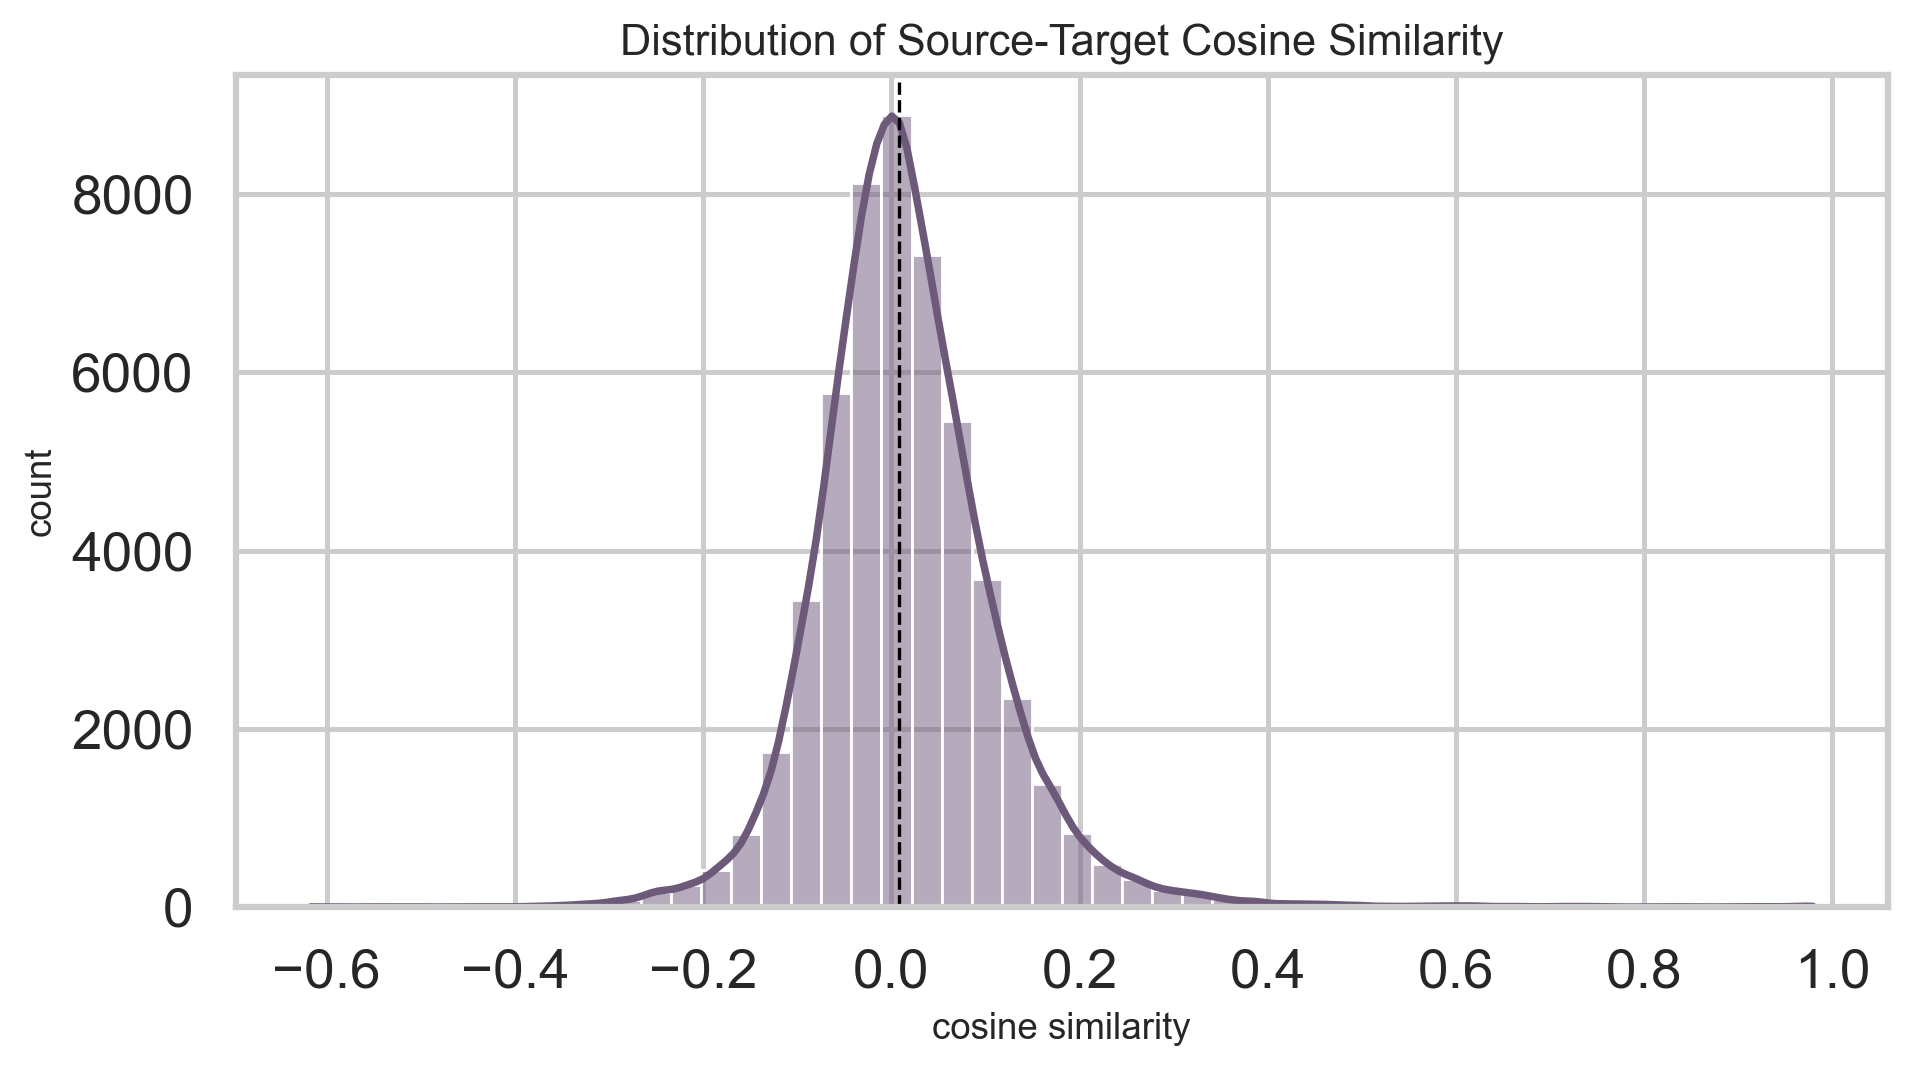

In [37]:
fig, ax = plt.subplots(figsize=(8.3, 4.8))
sns.histplot(similarity_df['cosine_similarity'], bins=50, color='#6d597a', kde=True, ax=ax)
ax.axvline(similarity_df['cosine_similarity'].median(), color='black', lw=1, ls='--')
ax.set_title('Distribution of Source-Target Cosine Similarity')
ax.set_xlabel('cosine similarity')
ax.set_ylabel('count')
plt.tight_layout()
save_and_show(fig, 'source_target_similarity_distribution.png')


Saved: /Users/izhan/Desktop/groundwater/stephanie_thesis_groundwater/Data/processed/figures_eda/best_source_similarity_by_site.png


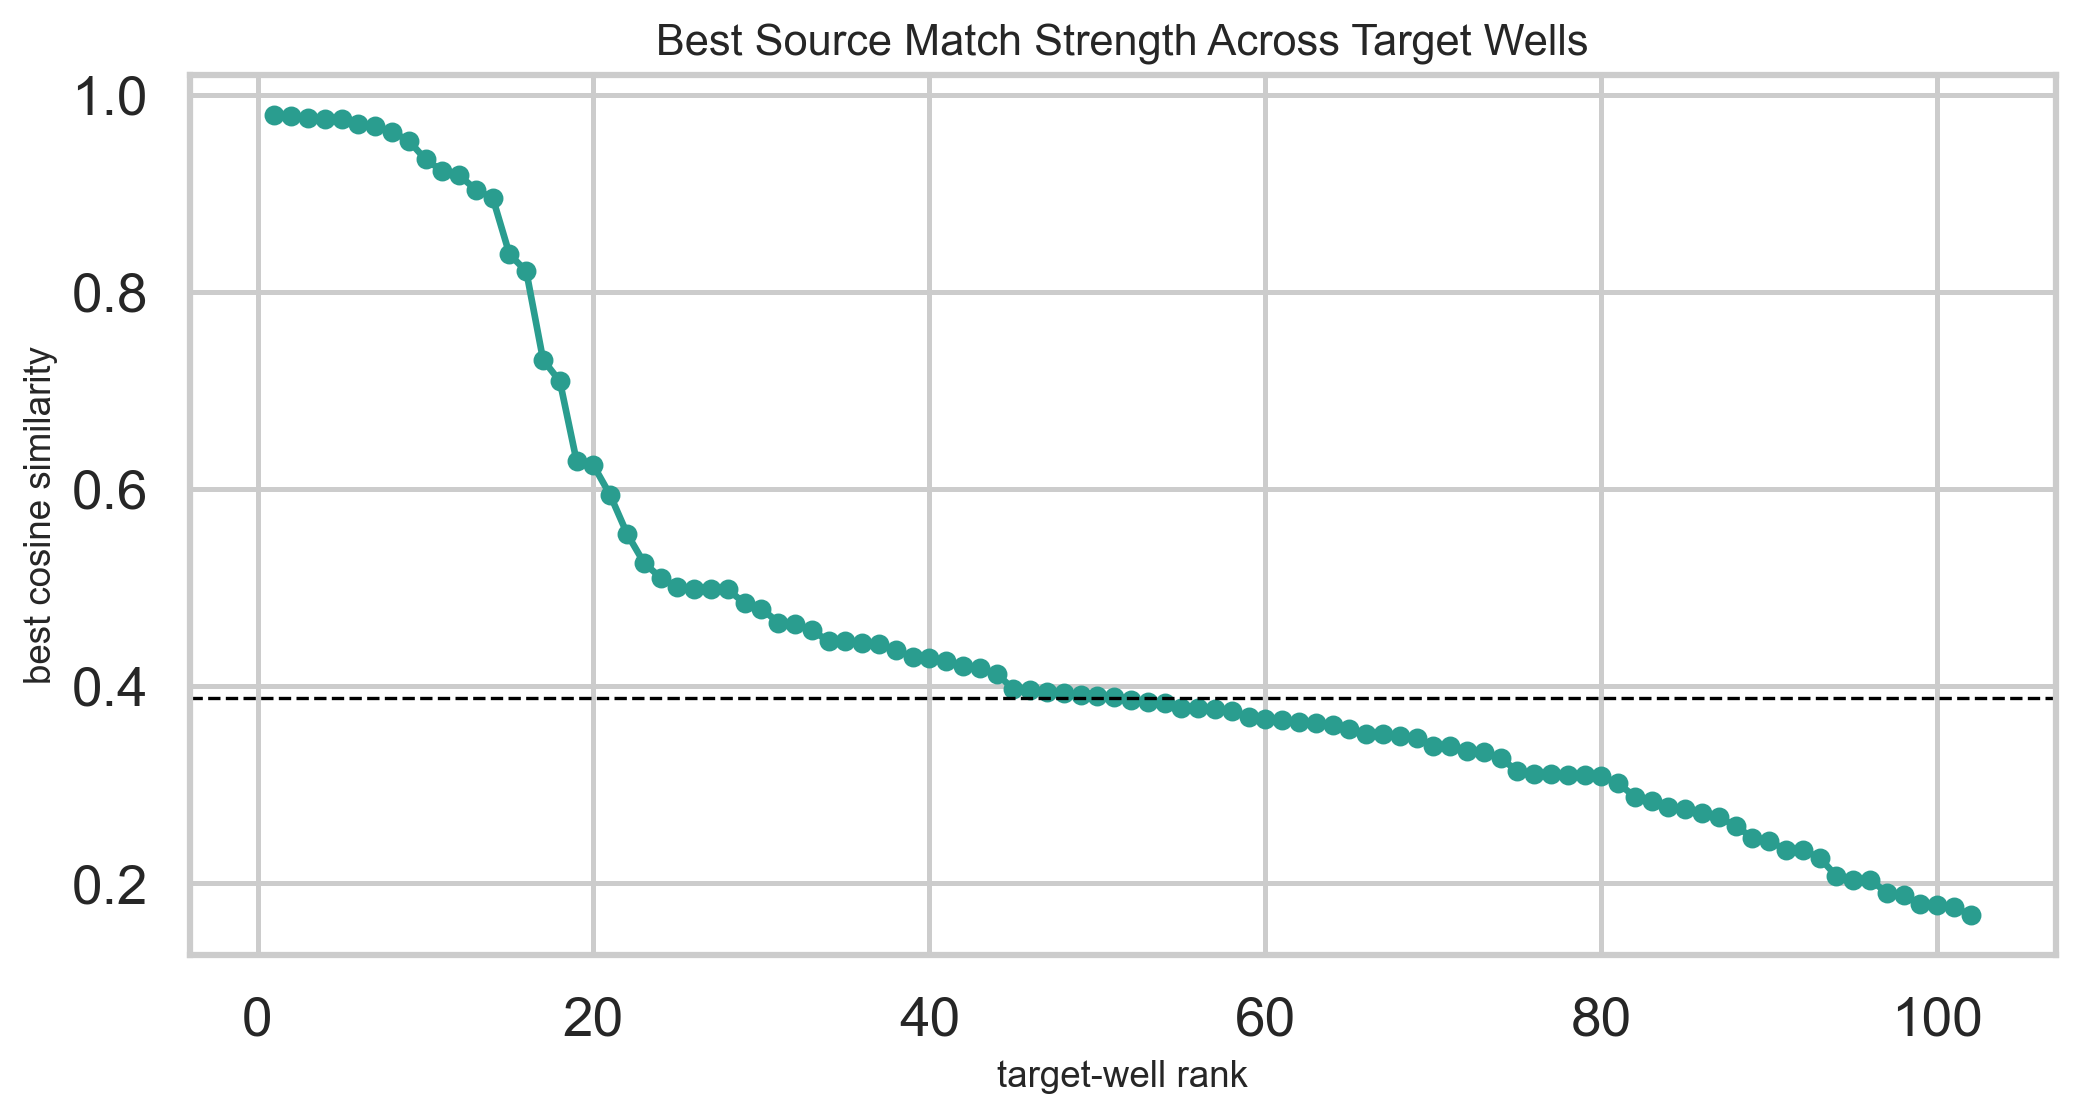

In [38]:
plot_df = best_matches.sort_values('cosine_similarity', ascending=False).reset_index(drop=True).copy()
plot_df['rank'] = np.arange(1, len(plot_df) + 1)

fig, ax = plt.subplots(figsize=(9.0, 5.0))
ax.plot(plot_df['rank'], plot_df['cosine_similarity'], color='#2a9d8f', lw=2)
ax.scatter(plot_df['rank'], plot_df['cosine_similarity'], color='#2a9d8f', s=20)
ax.axhline(plot_df['cosine_similarity'].median(), color='black', lw=1, ls='--')
ax.set_title('Best Source Match Strength Across Target Wells')
ax.set_xlabel('target-well rank')
ax.set_ylabel('best cosine similarity')
plt.tight_layout()
save_and_show(fig, 'best_source_similarity_by_site.png')


The similarity distribution supports a ranking view of transfer. I do not see a single uniformly strong source pool. Instead, I see a few much better matches for each target well.


# Summary and Conclusions

I finish the EDA with a short summary of the main descriptive findings.


I summarize the main descriptive findings below.

1. Corpus-level overview
- I keep 102 target wells in the main analysis standard.
- I observe local monthly anomalies for 102 wells in the EDA tables.
- I use 512 source cells in the similarity pool.

2. Target-variable behaviour
- The mean `wtda` is `-0.006`.
- The median `wtda` is `0.023`.
- The standard deviation of `wtda` is `1.550`.

3. Heterogeneity
- The median strongest site-level response is `0.229`.
- The strongest site-level response ranges from `0.081` to `0.610`.

4. Source-target similarity
- The median pairwise similarity is `0.008`.
- The median best-match similarity is `0.388`.
- The best-match similarity ranges from `0.168` to `0.979`.
